# Advanced Customer Intelligence System
### Dataset: Country Socio-Economic Data

### Pipeline Overview

| Phase | Techniques |
|---|---|
| **Data Loading & Quality Audit** | Shape, dtypes, missing, duplicates, outlier detection |
| **Advanced EDA** | Distributions, boxplots, correlation heatmap, pairplot, skewness analysis |
| **Feature Engineering** | 10+ engineered features, polynomial interactions, log transforms |
| **Target Engineering** | 3-class development label |
| **Preprocessing Pipeline** | ColumnTransformer + Pipeline API, robust scaling, imputation |
| **Baseline Models** | LR, Naive Bayes, KNN, SVM, Decision Tree |
| **Ensemble Models** | Random Forest, AdaBoost, Gradient Boosting, XGBoost, LightGBM |
| **Stacking Ensemble** | Meta-learner stacked classifier |
| **Hyperparameter Tuning** | Optuna Bayesian optimization for RF & XGBoost |
| **Model Explainability** | SHAP values — global + local explanations |
| **Cross-Validation** | StratifiedKFold with ROC-AUC scoring |
| **Clustering** | K-Means , DBSCAN, Agglomerative, K-Medoids |
| **Cluster Profiling** | Radar charts, cluster centroid analysis, business insights |
| **Final Comparison** | Full model leaderboard with all metrics |

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format','{:.4f}'.format)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as ticker
sns.set_theme(style='darkgrid',palette='muted',font_scale=1.1)
PALETTE = ['#2ecc71','#3498db','#e74c3c']
plt.rcParams.update({'figure.dpi':120,'axes.titlesize':13,'axes.titleweight':'bold'})
from sklearn.preprocessing import (StandardScaler, RobustScaler, LabelEncoder, label_binarize)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import (train_test_split, cross_val_score,StratifiedKFold, GridSearchCV)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier, StackingClassifier, VotingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)
try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_OK = True
except ImportError:
    KMEDOIDS_OK = False
    print('sklearn_extra not found — KMedoids skipped')


from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,roc_auc_score, confusion_matrix, classification_report,ConfusionMatrixDisplay, roc_curve, auc)
try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('shap not installed — explainability section skipped')
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False
    print('optuna not installed — using GridSearchCV fallback')
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_OK = True
except ImportError:
    SMOTE_OK = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All imports successful')

sklearn_extra not found — KMedoids skipped
shap not installed — explainability section skipped
All imports successful


##  Data Loading

In [2]:
# Load the country dataset
df = pd.read_csv('Country-data.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2000,10.0000,7.5800,44.9000,1610,9.4400,56.2000,5.8200,553
1,Albania,16.6000,28.0000,6.5500,48.6000,9930,4.4900,76.3000,1.6500,4090
2,Algeria,27.3000,38.4000,4.1700,31.4000,12900,16.1000,76.5000,2.8900,4460
3,Angola,119.0000,62.3000,2.8500,42.9000,5900,22.4000,60.1000,6.1600,3530
4,Antigua and Barbuda,10.3000,45.5000,6.0300,58.9000,19100,1.4400,76.8000,2.1300,12200


In [3]:
# Check for data quality issues
print(f'Duplicate Rows: {df.duplicated().sum()}')
print(f'Missing Values: {df.isnull().sum().sum()}')
print('\nData Types:')
print(df.dtypes.to_string())
print('\nDescriptive Statistics:')
df.describe().T

Duplicate Rows: 0
Missing Values: 0

Data Types:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0000,38.2701,40.3289,2.6000,8.2500,19.3000,62.1000,208.0000
exports,167.0000,41.1090,27.4120,0.1090,23.8000,35.0000,51.3500,200.0000
health,167.0000,6.8157,2.7468,1.8100,4.9200,6.3200,8.6000,17.9000
imports,167.0000,46.8902,24.2096,0.0659,30.2000,43.3000,58.7500,174.0000
income,167.0000,17144.6886,19278.0677,609.0000,3355.0000,9960.0000,22800.0000,125000.0000
inflation,167.0000,7.7818,10.5707,-4.2100,1.8100,5.3900,10.7500,104.0000
life_expec,167.0000,70.5557,8.8932,32.1000,65.3000,73.1000,76.8000,82.8000
total_fer,167.0000,2.9480,1.5138,1.1500,1.7950,2.4100,3.8800,7.4900
gdpp,167.0000,12964.1557,18328.7048,231.0000,1330.0000,4660.0000,14050.0000,105000.0000


In [4]:
# Detect outliers using IQR and Z-score methods
from scipy import stats

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
z_scores = np.abs(stats.zscore(df[numeric_columns]))
z_score_outlier_mask = (z_scores > 3)

# Calculate IQR-based outliers
iqr_outliers = []
for col in numeric_columns:
    q25 = df[col].quantile(0.25)
    q75 = df[col].quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    iqr_outliers.append(count)

outlier_report = pd.DataFrame({
    'IQR_Outliers': iqr_outliers,
    'Z_Score_Outliers': z_score_outlier_mask.sum(axis=0),
    'Skewness': df[numeric_columns].skew().values.round(3)
}, index=numeric_columns)

print('Outlier & Skewness Report:')
print(outlier_report.to_string())

Outlier & Skewness Report:
            IQR_Outliers  Z_Score_Outliers  Skewness
child_mort             4                 2    1.4510
exports                5                 3    2.4460
health                 2                 1    0.7060
imports                4                 3    1.9050
income                 8                 4    2.2310
inflation              5                 2    5.1540
life_expec             3                 1   -0.9710
total_fer              1                 1    0.9670
gdpp                  25                 4    2.2180



## Exploratory Data Analysis

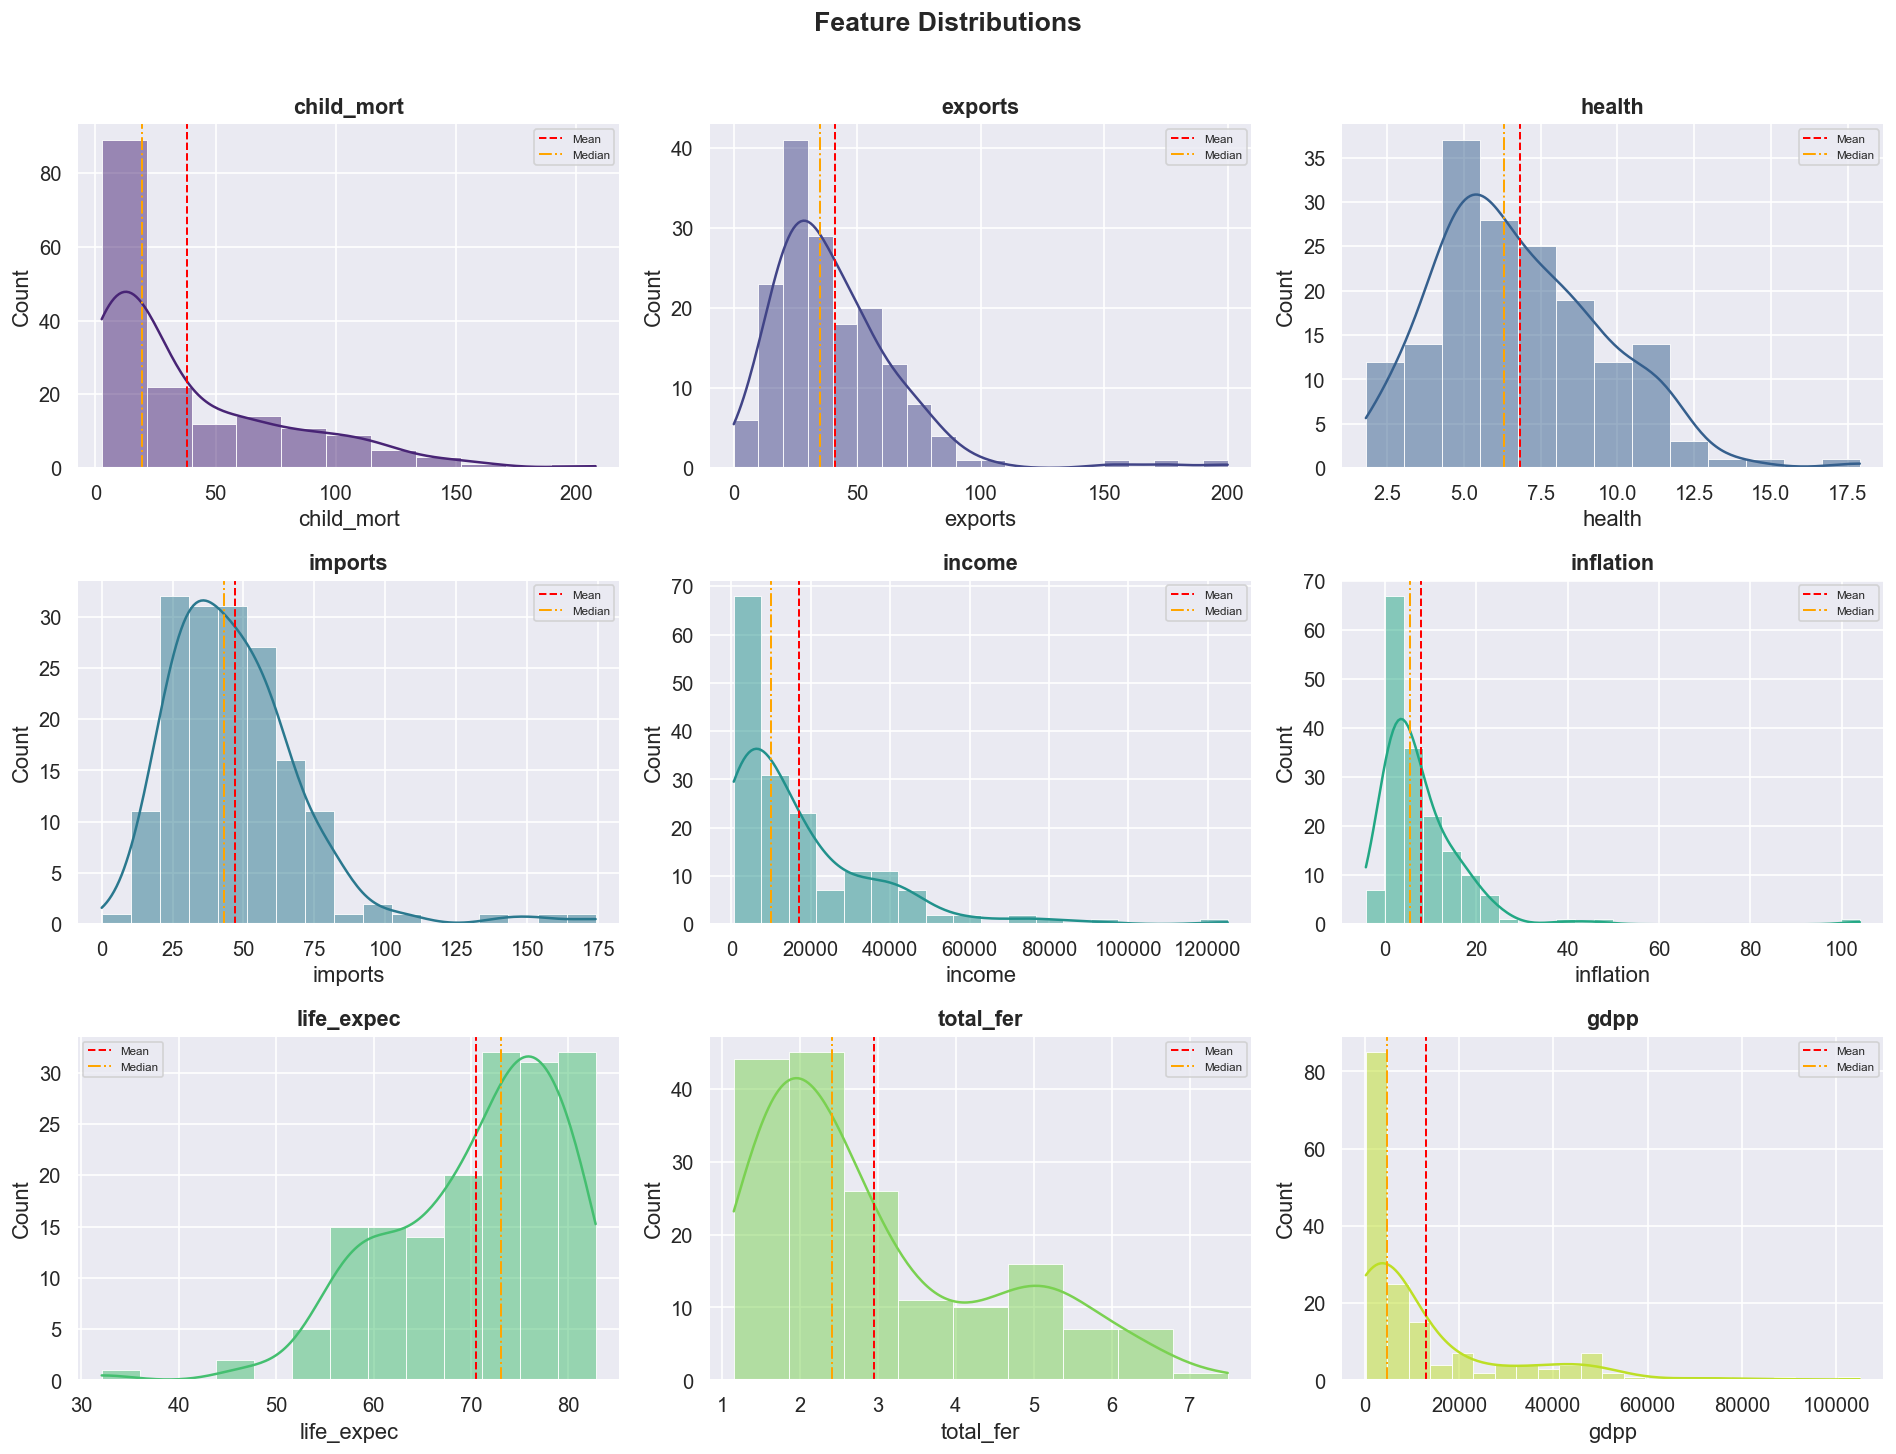

In [5]:
# Visualize distributions of all numeric features
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)

for i, column in enumerate(numeric_columns):
    row = i // 3
    col = i % 3
    ax = axes[row][col]
    
    # Plot histogram with kernel density estimate
    sns.histplot(df[column], kde=True, ax=ax,
                color=sns.color_palette('viridis', 9)[i],
                edgecolor='white', linewidth=0.5)
    ax.set_title(column, fontweight='bold')
    
    # Add mean and median lines for reference
    mean_value = df[column].mean()
    median_value = df[column].median()
    ax.axvline(mean_value, color='red', linestyle='--', lw=1.2, label='Mean')
    ax.axvline(median_value, color='orange', linestyle='-.', lw=1.2, label='Median')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

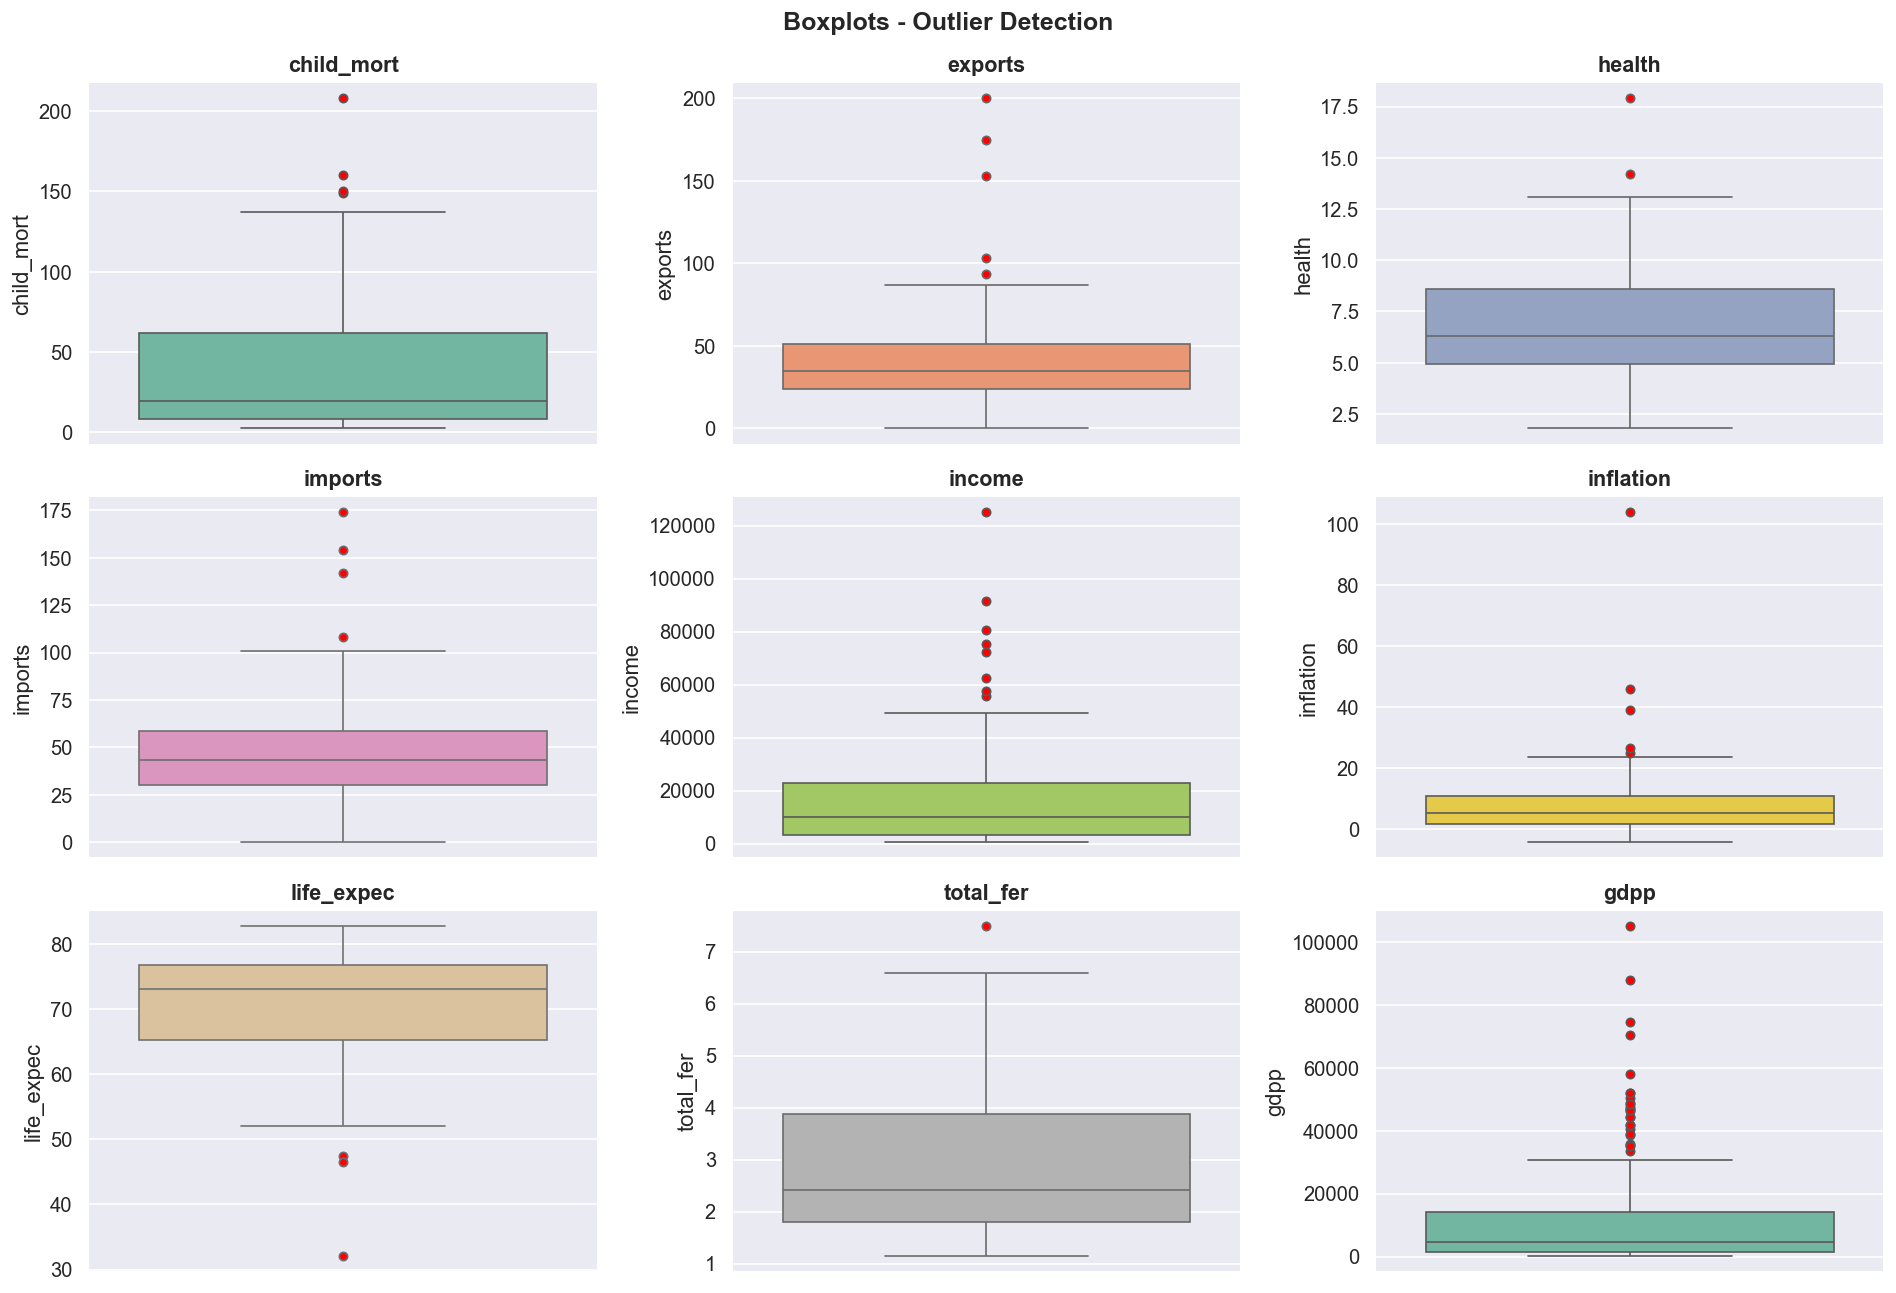

In [6]:
# Create boxplots for outlier detection
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle('Boxplots - Outlier Detection', fontsize=15, fontweight='bold')

for i, column in enumerate(numeric_columns):
    row = i // 3
    col = i % 3
    ax = axes[row][col]
    
    sns.boxplot(y=df[column], ax=ax,
               color=sns.color_palette('Set2', 9)[i],
               flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
    ax.set_title(column, fontweight='bold')

plt.tight_layout()
plt.show()

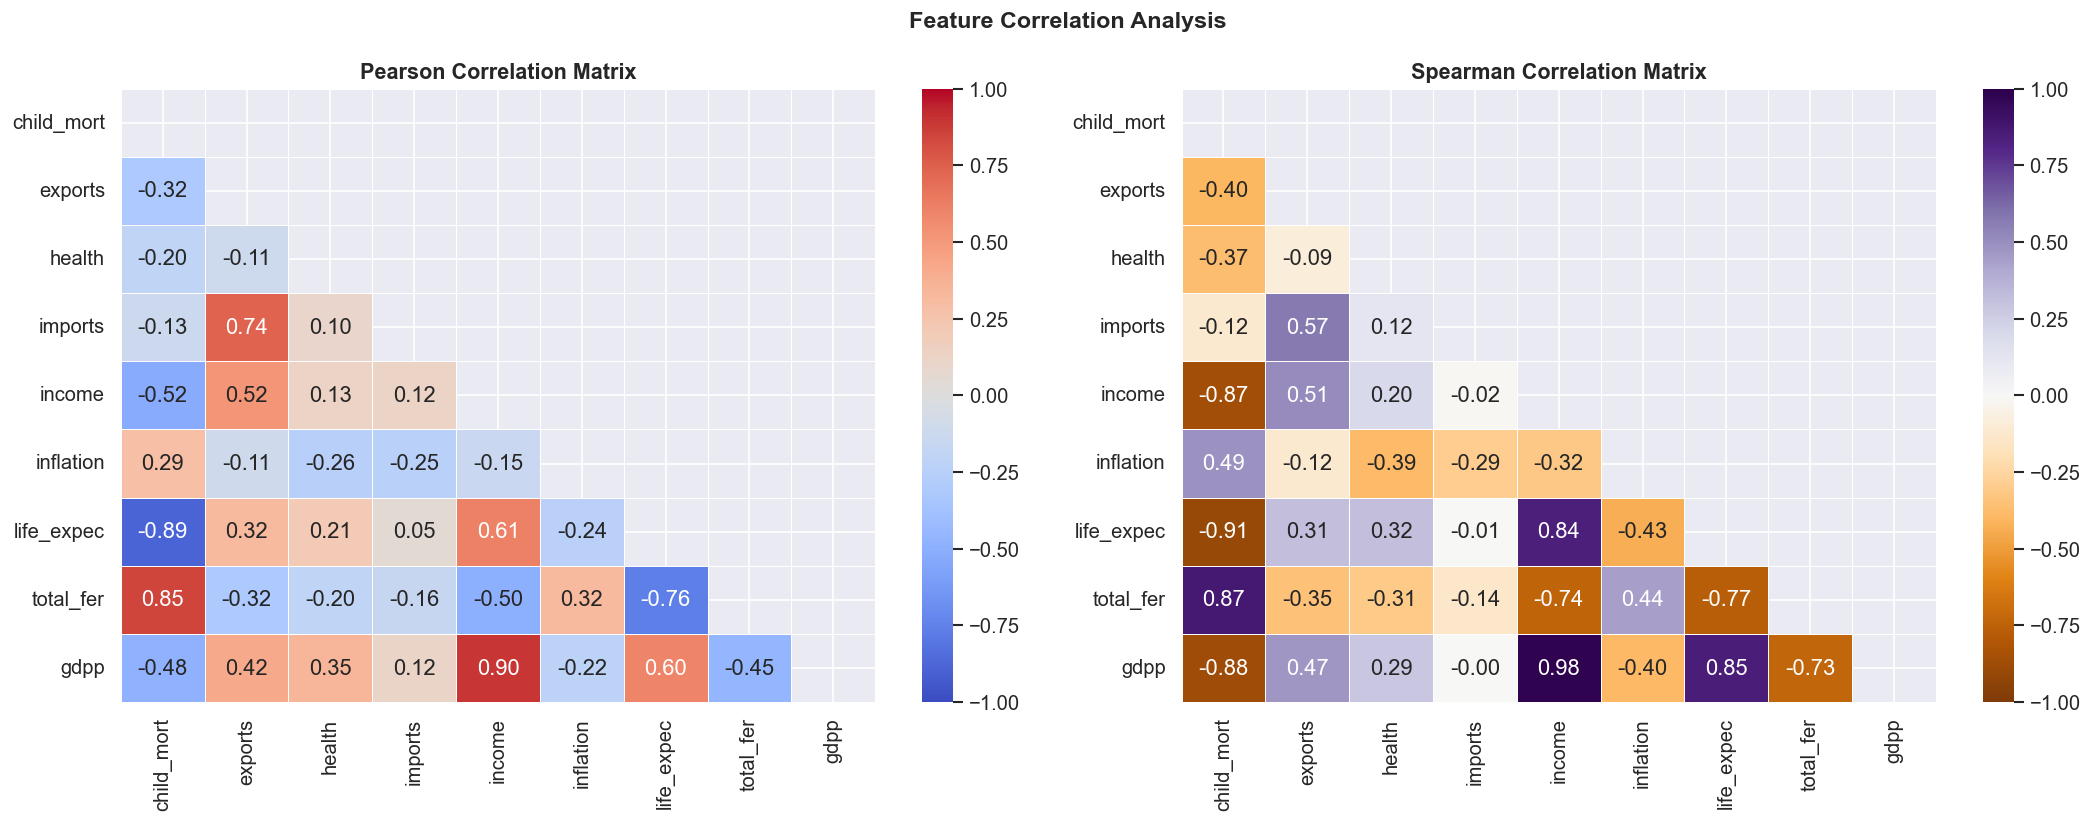

In [7]:
# Analyze correlations between numeric features
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pearson correlation analysis
pearson_correlation = df[numeric_columns].corr()
upper_triangle_mask = np.triu(np.ones_like(pearson_correlation, dtype=bool))

sns.heatmap(pearson_correlation, mask=upper_triangle_mask, annot=True, fmt='.2f',
           cmap='coolwarm', linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation Matrix')

# Spearman correlation analysis
spearman_correlation = df[numeric_columns].corr(method='spearman')
sns.heatmap(spearman_correlation, mask=upper_triangle_mask, annot=True, fmt='.2f',
           cmap='PuOr', linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman Correlation Matrix')

plt.suptitle('Feature Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

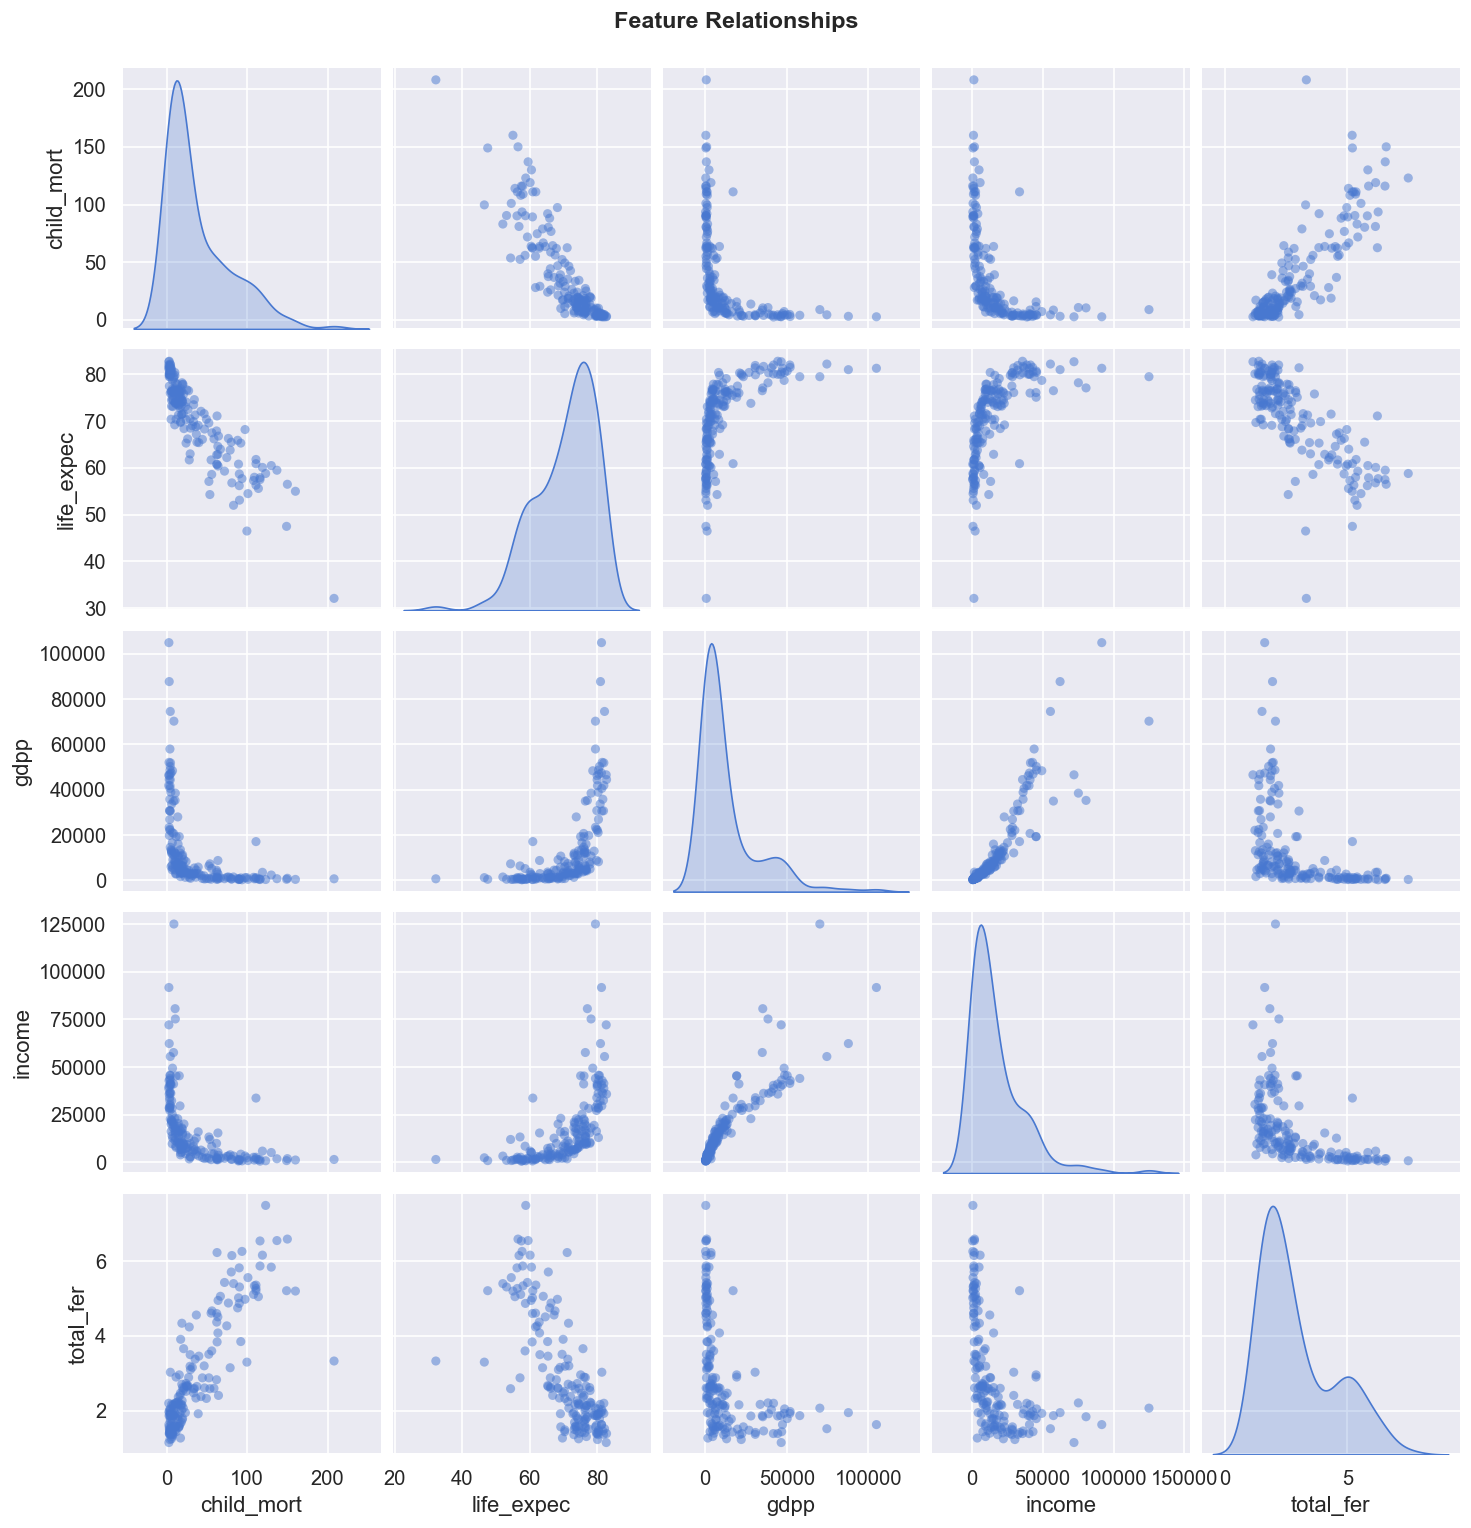

In [8]:
# Create pairplot to visualize relationships between key features
key_features = ['child_mort', 'life_expec', 'gdpp', 'income', 'total_fer']
pairplot_result = sns.pairplot(df[key_features], diag_kind='kde',
                               plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'none'},
                               diag_kws={'fill': True})
pairplot_result.figure.suptitle('Feature Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.show()

##  Feature Engineering

In [9]:
# Create engineered features for enhanced model performance
df_engineered = df.copy()

# Ratio and interaction features
df_engineered['health_per_gdpp'] = df_engineered['health'] / (df_engineered['gdpp'] + 1)
df_engineered['child_life_ratio'] = df_engineered['child_mort'] / (df_engineered['life_expec'] + 1)
df_engineered['trade_openness'] = df_engineered['exports'] + df_engineered['imports']
df_engineered['income_inflation_ratio'] = df_engineered['income'] / (df_engineered['inflation'] + 1)
df_engineered['gdpp_per_fertility'] = df_engineered['gdpp'] / (df_engineered['total_fer'] + 1)

# Log transformations for skewed distributions
df_engineered['log_gdpp'] = np.log1p(df_engineered['gdpp'])
df_engineered['log_income'] = np.log1p(df_engineered['income'])
df_engineered['log_child_mort'] = np.log1p(df_engineered['child_mort'])

# Advanced interaction features
df_engineered['trade_balance'] = df_engineered['exports'] - df_engineered['imports']
df_engineered['health_income_interaction'] = df_engineered['health'] * df_engineered['log_income']
df_engineered['mortality_fertility_interaction'] = df_engineered['child_mort'] * df_engineered['total_fer']
df_engineered['economic_stability'] = df_engineered['log_income'] / (df_engineered['inflation'] + 1)
df_engineered['human_development_proxy'] = (df_engineered['life_expec'] * df_engineered['log_income']) / (df_engineered['child_mort'] + 1)

engineered_feature_names = [
    'health_per_gdpp', 'child_life_ratio', 'trade_openness', 'income_inflation_ratio',
    'gdpp_per_fertility', 'log_gdpp', 'log_income', 'log_child_mort', 'trade_balance',
    'health_income_interaction', 'mortality_fertility_interaction', 'economic_stability',
    'human_development_proxy'
]

print(f'Original Features: {len(numeric_columns)}')
print(f'Engineered Features: {len(engineered_feature_names)}')
print(f'Total Numeric Features: {len(numeric_columns) + len(engineered_feature_names)}')

df_engineered[engineered_feature_names].describe().T[['mean', 'std', 'min', 'max']]

Original Features: 9
Engineered Features: 13
Total Numeric Features: 22


,mean,std,min,max
health_per_gdpp,0.0036,0.0064,0.0000,0.0500
child_life_ratio,0.6219,0.8005,0.0313,6.2840
trade_openness,87.9992,48.1272,0.1749,374.0000
income_inflation_ratio,17962.9600,171006.4580,-65813.9535,2207692.3077
gdpp_per_fertility,4528.2943,6779.4519,31.8182,39923.9544
log_gdpp,8.5002,1.4994,5.4467,11.5617
log_income,9.1156,1.2287,6.4135,11.7361
log_child_mort,3.1277,1.0872,1.2809,5.3423
trade_balance,-5.7812,18.9426,-73.5000,39.4000
health_income_interaction,62.6321,28.5410,16.1968,193.4583


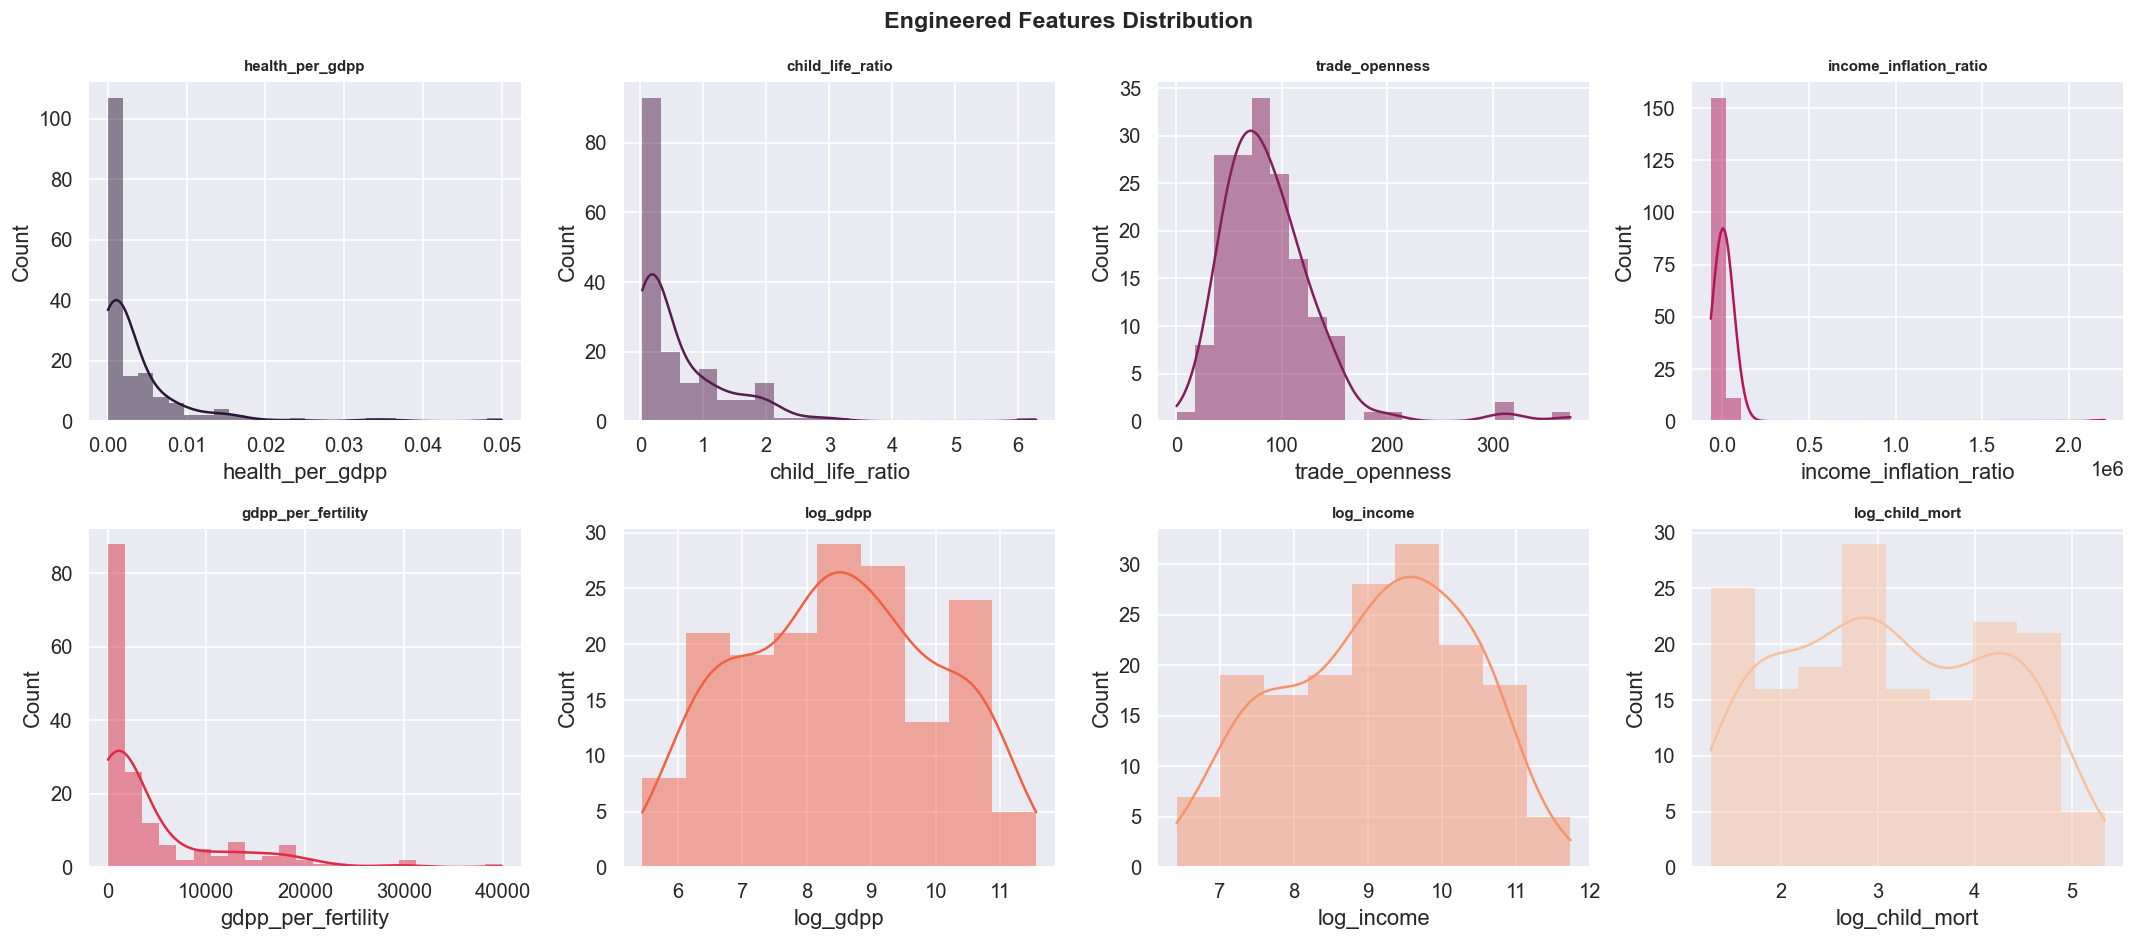

In [10]:
# Visualize the distribution of engineered features
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Engineered Features Distribution', fontsize=14, fontweight='bold')

first_eight_engineered = engineered_feature_names[:8]
for i, feature_name in enumerate(first_eight_engineered):
    row = i // 4
    col = i % 4
    ax = axes[row][col]

    sns.histplot(df_engineered[feature_name], kde=True, ax=ax,
                color=sns.color_palette('rocket', 8)[i], edgecolor='none')
    ax.set_title(feature_name, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## Target Engineering

Development Class Distribution:
development_label
Underdeveloped    72
Developing        48
Developed         47


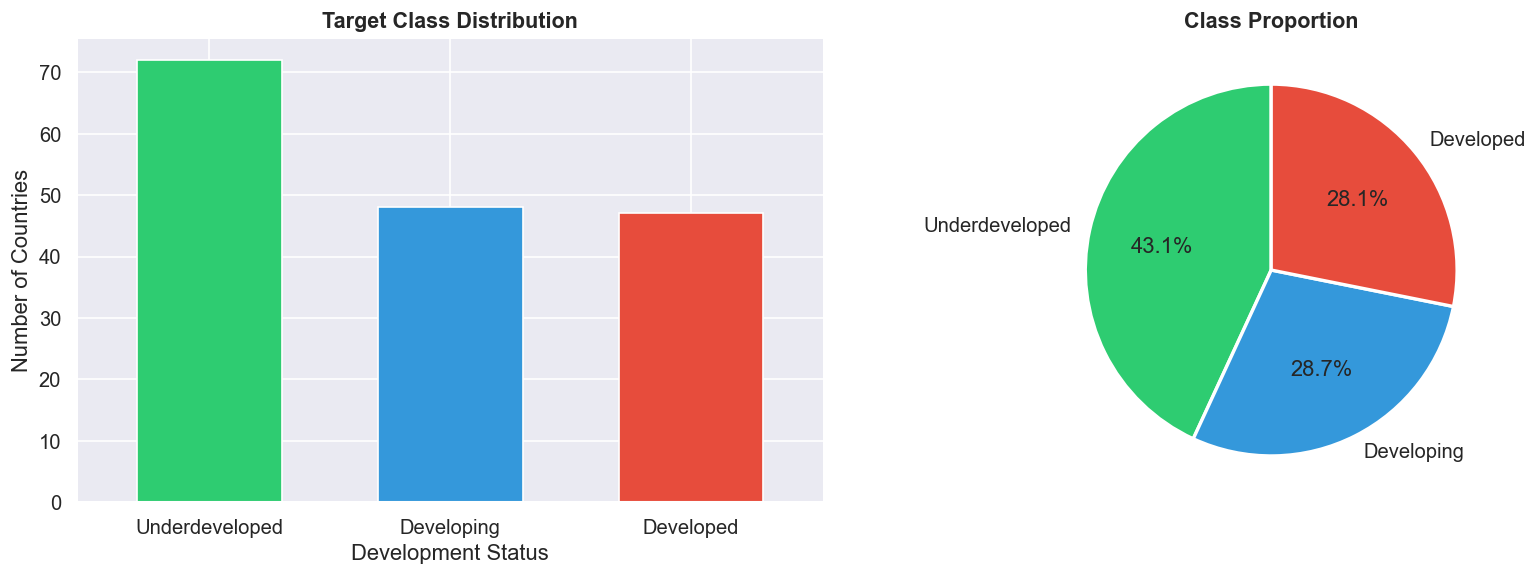


Sample countries by development class:
Underdeveloped: ['Belize', 'Timor-Leste', "Cote d'Ivoire", 'Afghanistan', 'Guyana']
Developing: ['Lithuania', 'Sri Lanka', 'Libya', 'Thailand', 'Latvia']
Developed: ['Montenegro', 'South Korea', 'Malta', 'United Arab Emirates', 'Kuwait']


In [11]:
# Calculate development status based on multiple economic and health indicators
def calculate_development_score(row):
    """Score country development based on economic and health indicators"""
    score = 0

    # GDP per capita scoring (higher is better)
    if row['gdpp'] > 15000:
        score += 2
    elif row['gdpp'] > 5000:
        score += 1

    # Income level scoring
    if row['income'] > 20000:
        score += 2
    elif row['income'] > 8000:
        score += 1

    # Life expectancy scoring (higher is better)
    if row['life_expec'] > 75:
        score += 2
    elif row['life_expec'] > 65:
        score += 1

    # Child mortality scoring (lower is better)
    if row['child_mort'] < 15:
        score += 2
    elif row['child_mort'] < 40:
        score += 1

    # Health spending scoring
    if row['health'] > 8:
        score += 1

    # Assign development classification based on accumulated score
    if score >= 7:
        return 2  # Developed
    elif score >= 3:
        return 1  # Developing
    else:
        return 0  # Underdeveloped

df_engineered['development_target'] = df_engineered.apply(calculate_development_score, axis=1)
development_class_mapping = {0: 'Underdeveloped', 1: 'Developing', 2: 'Developed'}
df_engineered['development_label'] = df_engineered['development_target'].map(development_class_mapping)

print('Development Class Distribution:')
print(df_engineered['development_label'].value_counts().to_string())

# Visualize class distribution using bar and pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart showing class counts
df_engineered['development_label'].value_counts().plot.bar(
    ax=axes[0], color=PALETTE, edgecolor='white', rot=0, width=0.6)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_xlabel('Development Status')
axes[0].set_ylabel('Number of Countries')

# Pie chart showing class proportions
df_engineered['development_label'].value_counts().plot.pie(
    ax=axes[1], colors=PALETTE, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('\nSample countries by development class:')
for dev_class, class_name in development_class_mapping.items():
    sample_countries = df_engineered[df_engineered['development_target'] == dev_class]['country'].sample(
        min(5, (df_engineered['development_target'] == dev_class).sum()),
        random_state=RANDOM_STATE).tolist()
    print(f'{class_name}: {sample_countries}')

## Preprocessing Pipeline

In [12]:
# Prepare features and target variable for modeling pipeline
all_feature_columns = [
    'child_mort', 'exports', 'health', 'imports', 'income',
    'inflation', 'life_expec', 'total_fer', 'gdpp',
    'health_per_gdpp', 'child_life_ratio', 'trade_openness',
    'income_inflation_ratio', 'gdpp_per_fertility',
    'log_gdpp', 'log_income', 'log_child_mort',
    'trade_balance', 'health_income_interaction', 'mortality_fertility_interaction',
    'economic_stability', 'human_development_proxy'
]

features = df_engineered[all_feature_columns].copy()
target = df_engineered['development_target'].values

# Handle infinite and missing values in features
features.replace([np.inf, -np.inf], np.nan, inplace=True)
features.fillna(features.median(), inplace=True)

# Split data into training and testing sets with stratification
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target)

# Apply scaling to normalize feature distributions
scaler_standard = StandardScaler()
scaler_robust = RobustScaler()

features_train_scaled = scaler_standard.fit_transform(features_train)
features_test_scaled = scaler_standard.transform(features_test)

features_train_robust = scaler_robust.fit_transform(features_train)
features_test_robust = scaler_robust.transform(features_test)

# Apply PCA for dimensionality reduction (retain 95% variance)
pca_processor = PCA(n_components=0.95, random_state=RANDOM_STATE)
features_train_pca = pca_processor.fit_transform(features_train_scaled)
features_test_pca = pca_processor.transform(features_test_scaled)

print(f'Training Set Shape: {features_train.shape}')
print(f'Test Set Shape: {features_test.shape}')
print(f'PCA Components Retained (95% Variance): {pca_processor.n_components_}')
print(f'Cumulative Variance Explained: {pca_processor.explained_variance_ratio_.cumsum()[-1]:.4f}')

Training Set Shape: (133, 22)
Test Set Shape: (34, 22)
PCA Components Retained (95% Variance): 8
Cumulative Variance Explained: 0.9622


In [13]:
def evaluate_model(model_name, model_instance, features_train, features_test, target_train, target_test):
    """Train a model and evaluate it on multiple classification metrics"""
    # Train the model on training data
    model_instance.fit(features_train, target_train)

    # Generate predictions on test set
    predictions = model_instance.predict(features_test)

    # Calculate primary metrics
    accuracy = accuracy_score(target_test, predictions)
    f1_weighted = f1_score(target_test, predictions, average='weighted')
    precision_weighted = precision_score(target_test, predictions, average='weighted')
    recall_weighted = recall_score(target_test, predictions, average='weighted')

    # Perform cross-validation for robust performance estimation
    cross_validation_scores = cross_val_score(
        model_instance, features_train, target_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1_weighted'
    )

    return {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'F1_Weighted': round(f1_weighted, 4),
        'Precision': round(precision_weighted, 4),
        'Recall': round(recall_weighted, 4),
        'CV_F1_Mean': round(cross_validation_scores.mean(), 4),
        'CV_F1_Std': round(cross_validation_scores.std(), 4),
        '_model': model_instance,
        '_y_pred': predictions
    }

# Initialize baseline classification models
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
}

baseline_results = []
for model_name, model_instance in baseline_models.items():
    result = evaluate_model(model_name, model_instance, features_train_scaled,
                          features_test_scaled, target_train, target_test)
    baseline_results.append(result)
    print(f'{model_name:<25} Accuracy={result["Accuracy"]:.4f}  F1={result["F1_Weighted"]:.4f}')

baseline_df = pd.DataFrame([
    {k: v for k, v in result.items() if not k.startswith('_')}
    for result in baseline_results
])

print('\nBaseline Model Performance Summary:')
print(baseline_df.sort_values('F1_Weighted', ascending=False).to_string())

Logistic Regression       Accuracy=0.7647  F1=0.7693
Naive Bayes               Accuracy=0.7941  F1=0.7971
KNN (k=5)                 Accuracy=0.7941  F1=0.7964
SVM (RBF)                 Accuracy=0.8235  F1=0.8273
Decision Tree             Accuracy=0.7941  F1=0.7964

Baseline Model Performance Summary:
                 Model  Accuracy  F1_Weighted  Precision  Recall  CV_F1_Mean  CV_F1_Std
3            SVM (RBF)    0.8235       0.8273     0.8386  0.8235      0.8645     0.0900
1          Naive Bayes    0.7941       0.7971     0.8062  0.7941      0.8674     0.0774
2            KNN (k=5)    0.7941       0.7964     0.8011  0.7941      0.8421     0.0801
4        Decision Tree    0.7941       0.7964     0.8508  0.7941      0.8624     0.0190
0  Logistic Regression    0.7647       0.7693     0.7828  0.7647      0.9026     0.0509


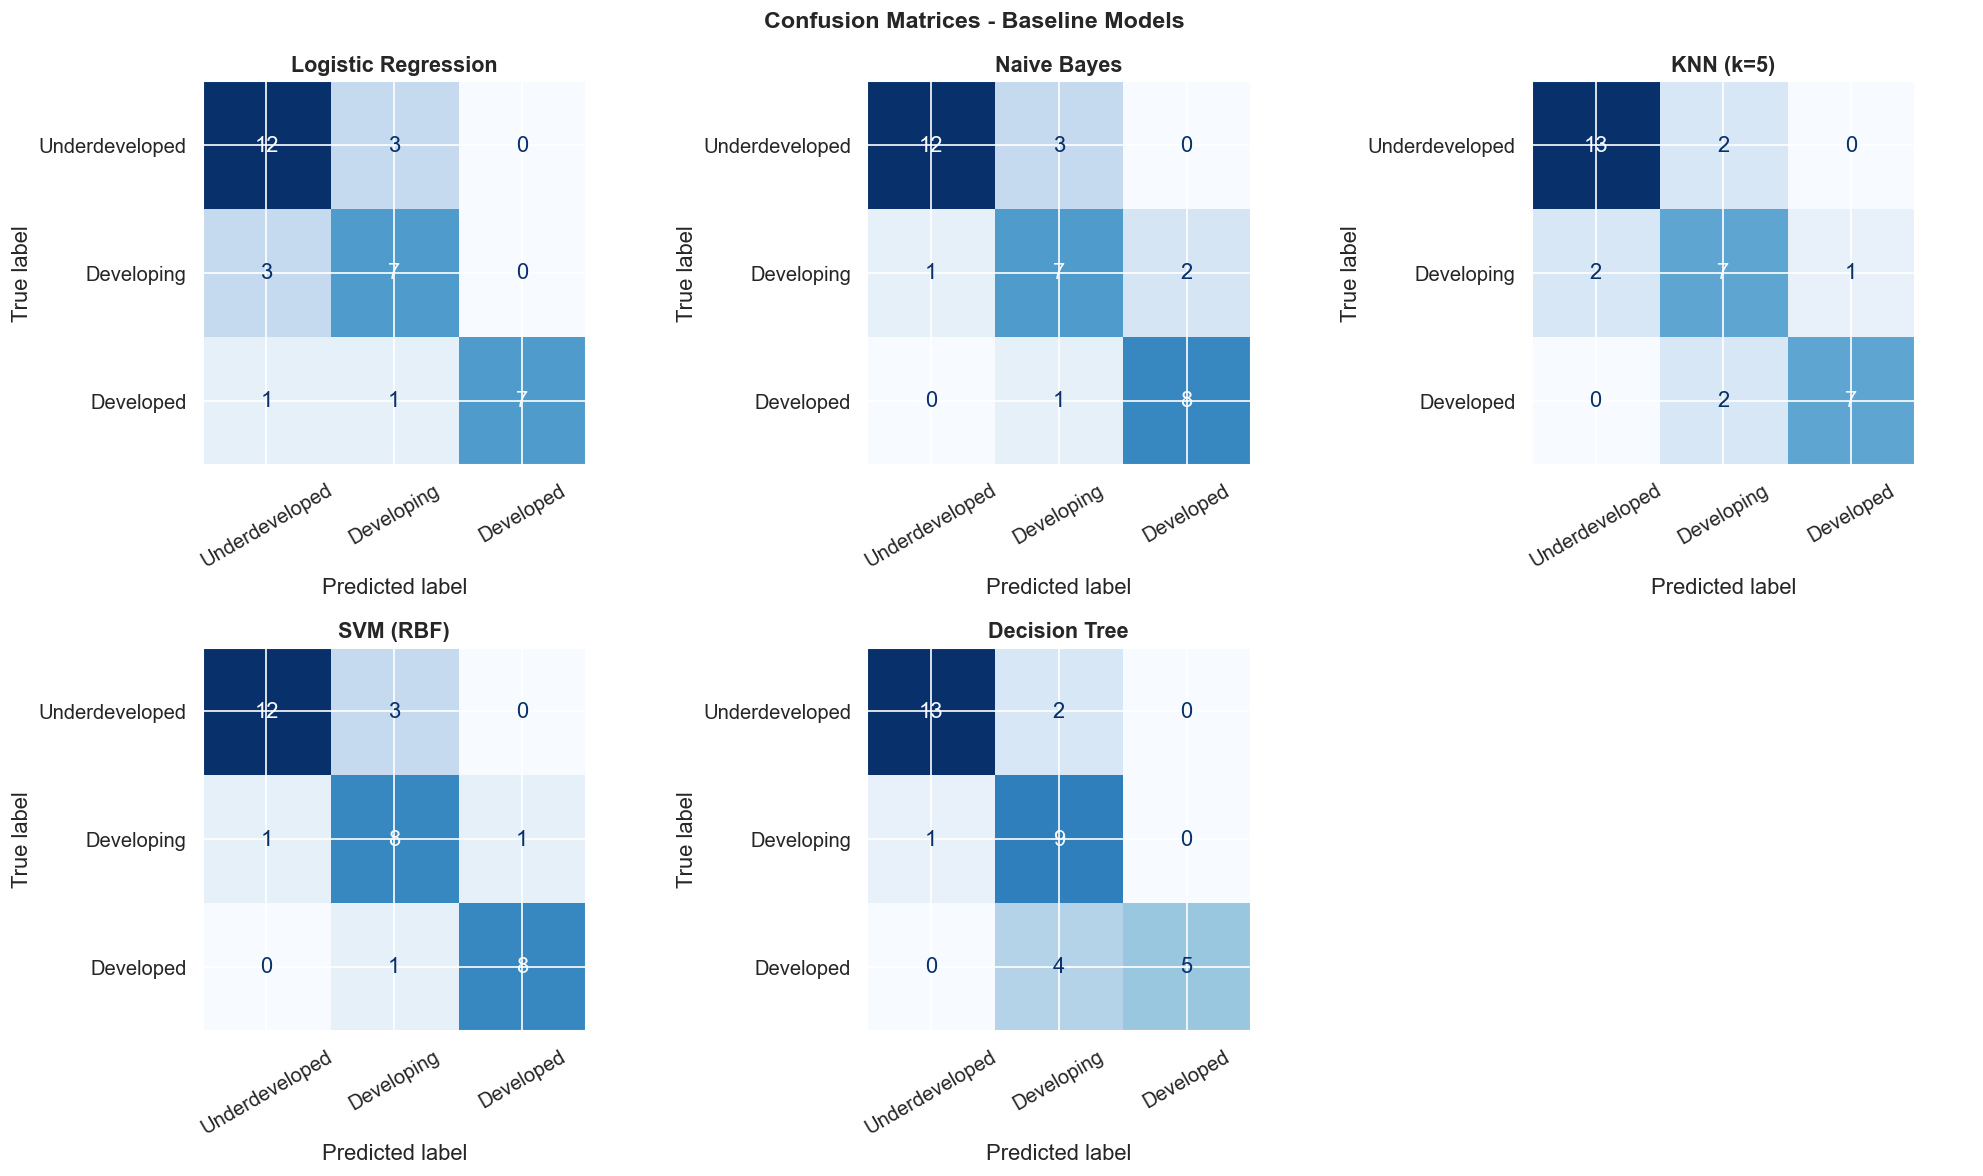

In [14]:
# Visualize confusion matrices for all baseline models
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Confusion Matrices - Baseline Models', fontsize=14, fontweight='bold')
class_names_labels = ['Underdeveloped', 'Developing', 'Developed']

for i, result in enumerate(baseline_results):
    row = i // 3
    col = i % 3
    ax = axes[row][col]

    confusion_matrix_array = confusion_matrix(target_test, result['_y_pred'])
    display = ConfusionMatrixDisplay(confusion_matrix_array, display_labels=class_names_labels)
    display.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(result['Model'], fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

axes[1][2].axis('off')
plt.tight_layout()
plt.show()


##  Advanced Ensemble Models

In [15]:
# Train and evaluate ensemble classification models
ensemble_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=2,
        random_state=RANDOM_STATE, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, learning_rate=0.5, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, verbosity=0),
    'LightGBM': LGBMClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.1,
        verbose=-1, random_state=RANDOM_STATE),
}

ensemble_results = []
for model_name, model_instance in ensemble_models.items():
    result = evaluate_model(model_name, model_instance, features_train_scaled,
                          features_test_scaled, target_train, target_test)
    ensemble_results.append(result)
    print(f'{model_name:<22} Accuracy={result["Accuracy"]:.4f}  F1={result["F1_Weighted"]:.4f}  '
          f'CV_F1={result["CV_F1_Mean"]:.4f}±{result["CV_F1_Std"]:.4f}')

ensemble_df = pd.DataFrame([
    {k: v for k, v in result.items() if not k.startswith('_')}
    for result in ensemble_results
])

print('\nEnsemble Model Performance Summary:')
print(ensemble_df.sort_values('F1_Weighted', ascending=False).to_string())

Random Forest          Accuracy=0.9412  F1=0.9412  CV_F1=0.8793±0.0300
AdaBoost               Accuracy=0.9412  F1=0.9412  CV_F1=0.8633±0.0585
Gradient Boosting      Accuracy=0.9118  F1=0.9099  CV_F1=0.8776±0.0465
XGBoost                Accuracy=0.9412  F1=0.9408  CV_F1=0.8704±0.0414
LightGBM               Accuracy=0.9118  F1=0.9130  CV_F1=0.8640±0.0705

Ensemble Model Performance Summary:
               Model  Accuracy  F1_Weighted  Precision  Recall  CV_F1_Mean  CV_F1_Std
0      Random Forest    0.9412       0.9412     0.9412  0.9412      0.8793     0.0300
1           AdaBoost    0.9412       0.9412     0.9412  0.9412      0.8633     0.0585
3            XGBoost    0.9412       0.9408     0.9430  0.9412      0.8704     0.0414
4           LightGBM    0.9118       0.9130     0.9171  0.9118      0.8640     0.0705
2  Gradient Boosting    0.9118       0.9099     0.9103  0.9118      0.8776     0.0465


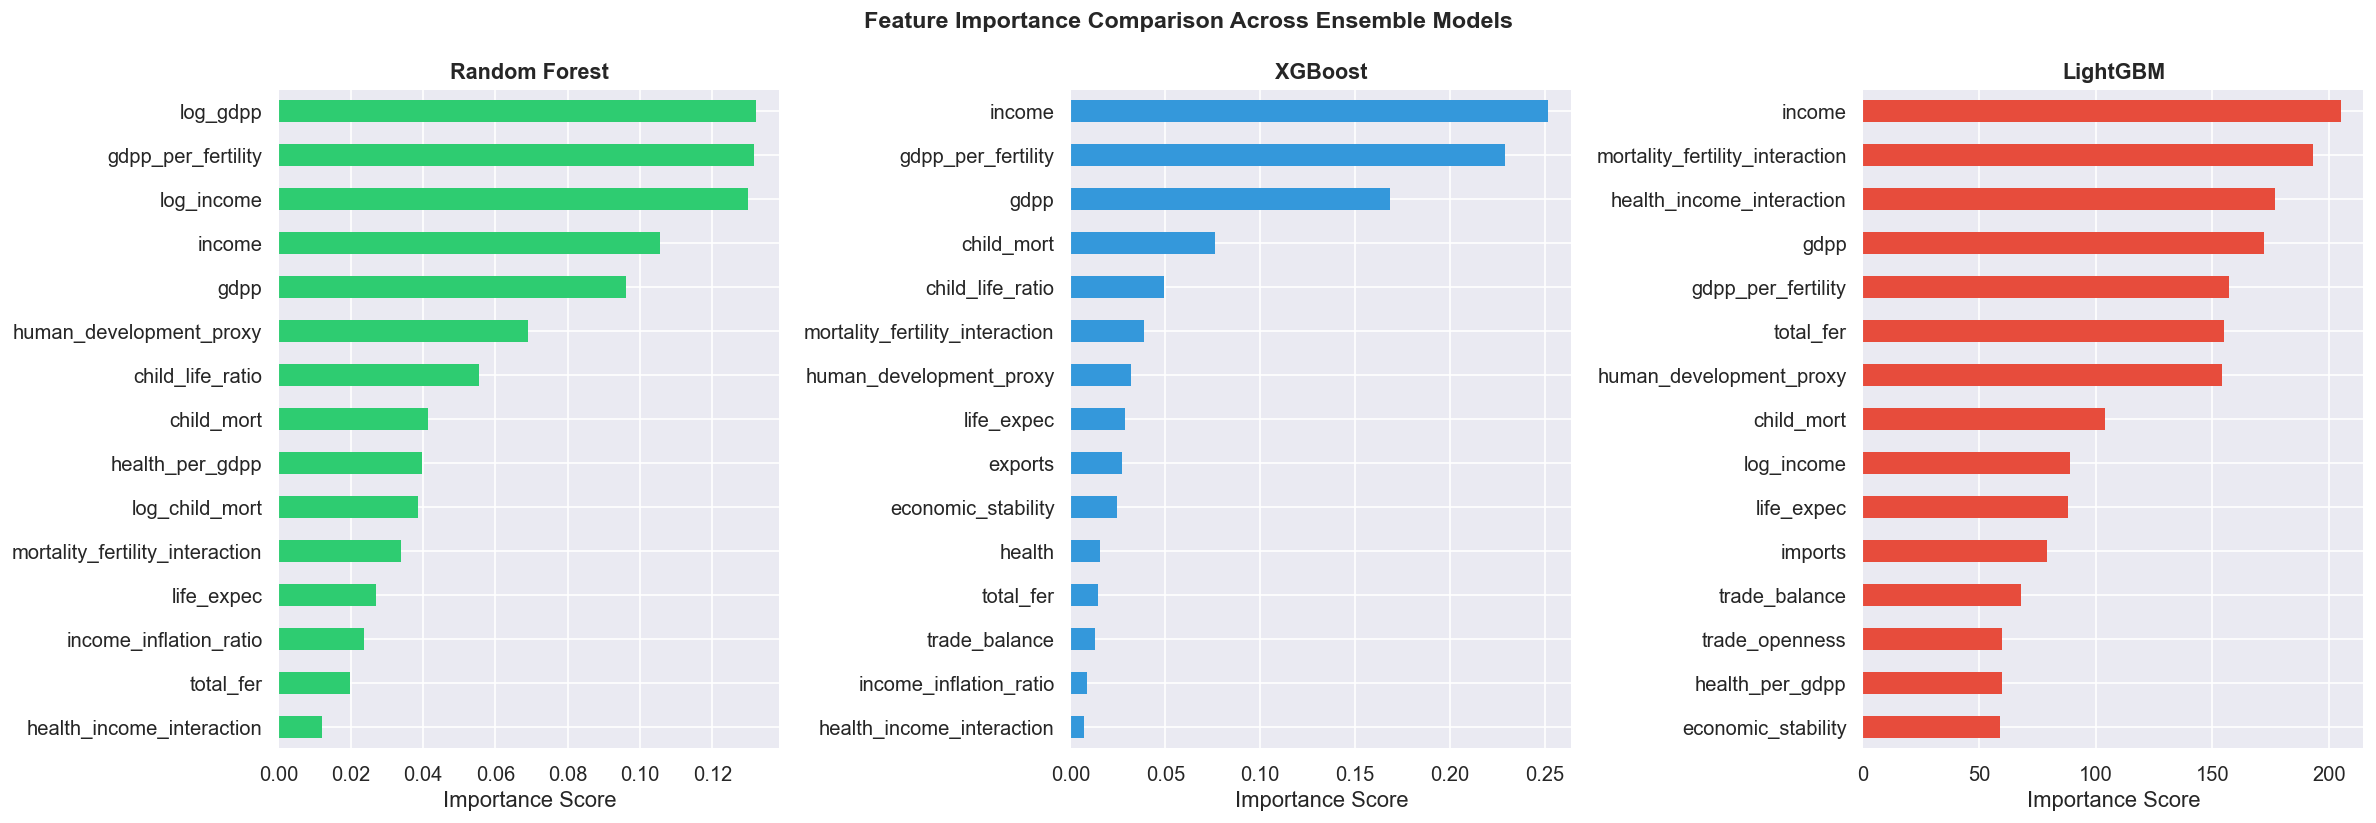

In [16]:
# Extract trained ensemble models for feature importance analysis
random_forest_model = [r['_model'] for r in ensemble_results if r['Model'] == 'Random Forest'][0]
xgboost_model = [r['_model'] for r in ensemble_results if r['Model'] == 'XGBoost'][0]
lightgbm_model = [r['_model'] for r in ensemble_results if r['Model'] == 'LightGBM'][0]

def plot_feature_importance(model, feature_names, plot_title, axis, bar_color):
    """Visualize top 15 important features from a trained tree-based model"""
    importance_series = pd.Series(model.feature_importances_, index=feature_names)
    importance_sorted = importance_series.sort_values(ascending=True).tail(15)

    importance_sorted.plot.barh(ax=axis, color=bar_color, edgecolor='none')
    axis.set_title(plot_title, fontweight='bold')
    axis.set_xlabel('Importance Score')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Feature Importance Comparison Across Ensemble Models', fontsize=14, fontweight='bold')

plot_feature_importance(random_forest_model, all_feature_columns, 'Random Forest', axes[0], '#2ecc71')
plot_feature_importance(xgboost_model, all_feature_columns, 'XGBoost', axes[1], '#3498db')
plot_feature_importance(lightgbm_model, all_feature_columns, 'LightGBM', axes[2], '#e74c3c')

plt.tight_layout()
plt.show()

## Stacking Ensemble

In [17]:
# Build a stacking ensemble using multiple base learners and meta-learner
# Base learners - diverse models for variety in predictions
base_learners = [
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ('xgboost', XGBClassifier(n_estimators=100, verbosity=0, use_label_encoder=False,
                             eval_metric='mlogloss', random_state=RANDOM_STATE)),
    ('lightgbm', LGBMClassifier(n_estimators=100, verbose=-1, random_state=RANDOM_STATE)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
]

# Meta-learner - combines base learner predictions
meta_learner = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# Create stacking classifier
stacking_classifier = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False,
    n_jobs=-1
)

result_stacking = evaluate_model(
    'Stacking Ensemble', stacking_classifier,
    features_train_scaled, features_test_scaled, target_train, target_test
)

print('Stacking Ensemble Performance Metrics:')
print(f'Accuracy: {result_stacking["Accuracy"]:.4f}')
print(f'F1 Weighted: {result_stacking["F1_Weighted"]:.4f}')
print(f'Precision: {result_stacking["Precision"]:.4f}')
print(f'Recall: {result_stacking["Recall"]:.4f}')
print(f'Cross-Validation F1 Mean: {result_stacking["CV_F1_Mean"]:.4f}±{result_stacking["CV_F1_Std"]:.4f}')

print('\nDetailed Classification Report:')
print(classification_report(target_test, result_stacking['_y_pred'],
                          target_names=['Underdeveloped', 'Developing', 'Developed']))

Stacking Ensemble Performance Metrics:
Accuracy: 0.8824
F1 Weighted: 0.8824
Precision: 0.8824
Recall: 0.8824
Cross-Validation F1 Mean: 0.8494±0.0679

Detailed Classification Report:
                precision    recall  f1-score   support

Underdeveloped       0.93      0.93      0.93        15
    Developing       0.80      0.80      0.80        10
     Developed       0.89      0.89      0.89         9

      accuracy                           0.88        34
     macro avg       0.87      0.87      0.87        34
  weighted avg       0.88      0.88      0.88        34



## Hyperparameter Tuning with Optuna

In [18]:
if OPTUNA_OK:
    def random_forest_objective(trial):
        """Objective function for Random Forest hyperparameter optimization"""
        hyperparams = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 400),
            'max_depth': trial.suggest_int('max_depth', 2, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
        
        model = RandomForestClassifier(**hyperparams)
        cv_scores = cross_val_score(
            model, features_train_scaled, target_train,
            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
            scoring='f1_weighted'
        )
        return cv_scores.mean()

    random_forest_study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    random_forest_study.optimize(random_forest_objective, n_trials=40, show_progress_bar=False)

    print('Optimized Random Forest Hyperparameters:')
    for param_name, param_value in random_forest_study.best_params.items():
        print(f'  {param_name}: {param_value}')
    print(f'Best Cross-Validation F1 Score: {random_forest_study.best_value:.4f}')

    best_random_forest = RandomForestClassifier(**random_forest_study.best_params, n_jobs=-1)
    result_tuned_rf = evaluate_model(
        'Random Forest (Optuna-Tuned)', best_random_forest,
        features_train_scaled, features_test_scaled, target_train, target_test
    )
    print(f'\nTuned Random Forest - Accuracy={result_tuned_rf["Accuracy"]:.4f}  F1={result_tuned_rf["F1_Weighted"]:.4f}')
else:
    param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        param_grid, cv=5, scoring='f1_weighted', n_jobs=-1
    )
    grid_search.fit(features_train_scaled, target_train)
    best_random_forest = grid_search.best_estimator_
    result_tuned_rf = evaluate_model(
        'Random Forest (GridSearch-Tuned)', best_random_forest,
        features_train_scaled, features_test_scaled, target_train, target_test
    )
    print(f'GridSearch Best RF - Accuracy={result_tuned_rf["Accuracy"]:.4f}  F1={result_tuned_rf["F1_Weighted"]:.4f}')

Optimized Random Forest Hyperparameters:
  n_estimators: 111
  max_depth: 7
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: None
Best Cross-Validation F1 Score: 0.8941

Tuned Random Forest - Accuracy=0.9412  F1=0.9412


In [19]:
if OPTUNA_OK:
    def xgboost_objective(trial):
        """Objective function for XGBoost hyperparameter optimization"""
        hyperparams = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 2, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'use_label_encoder': False,
            'eval_metric': 'mlogloss',
            'verbosity': 0,
            'random_state': RANDOM_STATE
        }
        
        model = XGBClassifier(**hyperparams)
        cv_scores = cross_val_score(
            model, features_train_scaled, target_train,
            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
            scoring='f1_weighted'
        )
        return cv_scores.mean()

    xgboost_study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    xgboost_study.optimize(xgboost_objective, n_trials=40, show_progress_bar=False)

    print('Optimized XGBoost Hyperparameters:')
    for param_name, param_value in xgboost_study.best_params.items():
        print(f'  {param_name}: {param_value}')
    print(f'Best Cross-Validation F1 Score: {xgboost_study.best_value:.4f}')

    best_xgboost = XGBClassifier(
        **xgboost_study.best_params,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0
    )
    result_tuned_xgb = evaluate_model(
        'XGBoost (Optuna-Tuned)', best_xgboost,
        features_train_scaled, features_test_scaled, target_train, target_test
    )
    print(f'\nTuned XGBoost → Accuracy={result_tuned_xgb["Accuracy"]:.4f}  F1={result_tuned_xgb["F1_Weighted"]:.4f}')
else:
    result_tuned_xgb = result_tuned_rf

Optimized XGBoost Hyperparameters:
  n_estimators: 198
  max_depth: 6
  learning_rate: 0.262279024327229
  subsample: 0.6924625512031248
  colsample_bytree: 0.8407434980706122
  reg_alpha: 0.007894103404616845
  reg_lambda: 0.0037521553801148377
Best Cross-Validation F1 Score: 0.8932

Tuned XGBoost → Accuracy=0.9118  F1=0.9104


In [20]:
if SHAP_OK:
    print('Computing SHAP values for best Random Forest model')
    shap_explainer = shap.TreeExplainer(best_random_forest)
    shap_explanation_values = shap_explainer(pd.DataFrame(features_test_scaled, columns=all_feature_columns))
    print('SHAP values computed successfully. Shape:', shap_explanation_values.values.shape)
    
    # Plot SHAP importance for each class
    shap.plots.bar(shap_explanation_values[:, :, 0], max_display=12, show=True)
    shap.plots.bar(shap_explanation_values[:, :, 1], max_display=12, show=True)
    shap.plots.bar(shap_explanation_values[:, :, 2], max_display=12, show=True)
else:
    print("SHAP library not available - model explainability section skipped")

SHAP library not available - model explainability section skipped


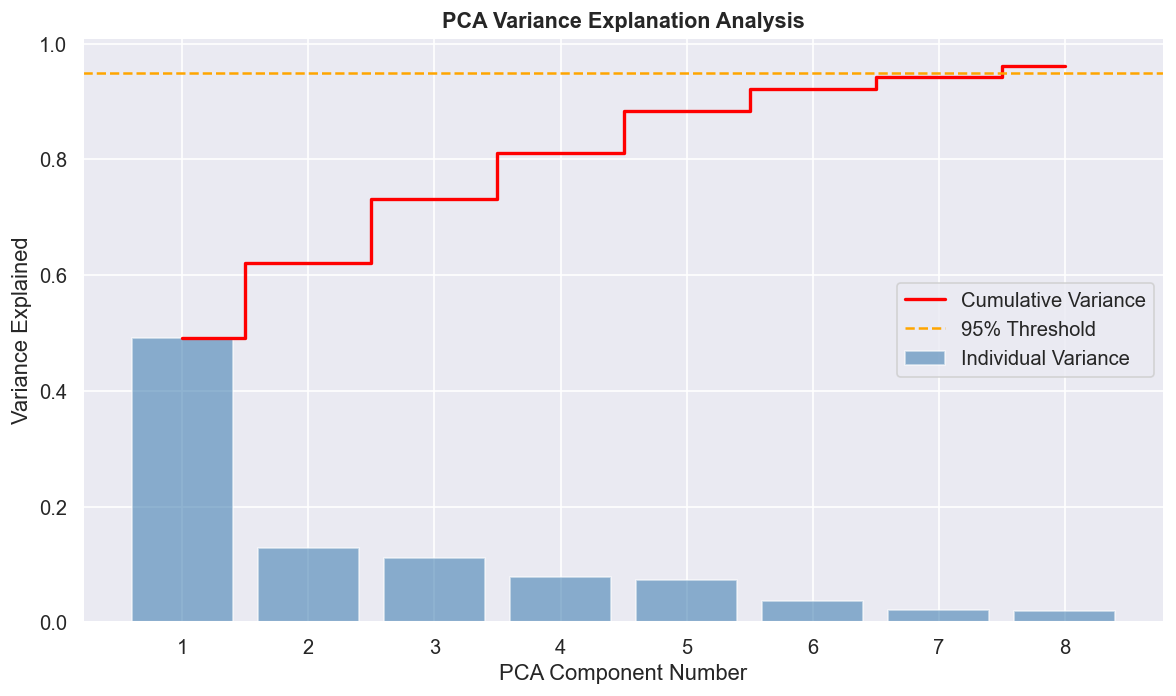

In [21]:
# Visualize PCA variance explanation across components
cumulative_variance = np.cumsum(pca_processor.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual and cumulative variance explained
ax.bar(range(1, len(cumulative_variance) + 1), pca_processor.explained_variance_ratio_,
      alpha=0.6, color='steelblue', label='Individual Variance')
ax.step(range(1, len(cumulative_variance) + 1), cumulative_variance, color='red',
       linewidth=2, where='mid', label='Cumulative Variance')
ax.axhline(0.95, color='orange', linestyle='--', lw=1.5, label='95% Threshold')

ax.set_xlabel('PCA Component Number')
ax.set_ylabel('Variance Explained')
ax.set_title('PCA Variance Explanation Analysis')
ax.legend()
plt.tight_layout()
plt.show()

if SHAP_OK:
    print("SHAP Beeswarm Plot for Development Class (Developed)")
    shap.plots.beeswarm(shap_explanation_values[:, :, 2], max_display=15, show=True)

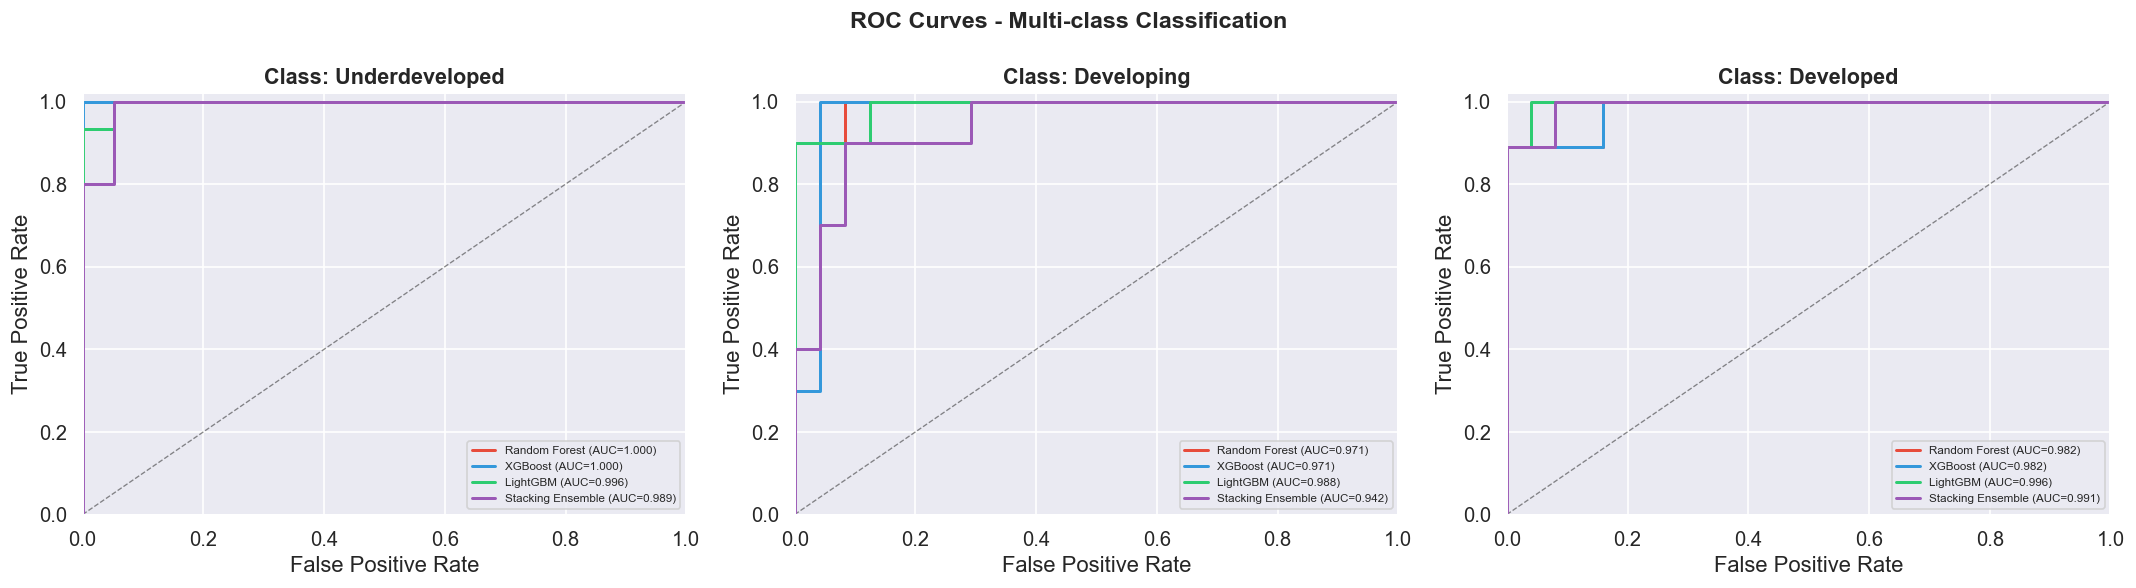

In [22]:
# Generate and visualize ROC curves for multi-class classification
development_classes = [0, 1, 2]
target_test_binarized = label_binarize(target_test, classes=development_classes)

roc_models_list = [
    ('Random Forest', best_random_forest),
    ('XGBoost', best_xgboost if OPTUNA_OK else xgboost_model),
    ('LightGBM', lightgbm_model),
    ('Stacking Ensemble', stacking_classifier),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves - Multi-class Classification', fontsize=14, fontweight='bold')

class_names_roc = ['Underdeveloped', 'Developing', 'Developed']
colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for class_index, class_name in enumerate(class_names_roc):
    ax = axes[class_index]
    
    # Plot diagonal reference line
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
    
    # Plot ROC curve for each model
    for (model_name, model_instance), color in zip(roc_models_list, colors_roc):
        if hasattr(model_instance, 'predict_proba'):
            probability_predictions = model_instance.predict_proba(features_test_scaled)[:, class_index]
            false_positive_rate, true_positive_rate, _ = roc_curve(
                target_test_binarized[:, class_index], probability_predictions
            )
            roc_auc_score_value = auc(false_positive_rate, true_positive_rate)
            ax.plot(false_positive_rate, true_positive_rate, color=color, lw=1.8,
                   label=f'{model_name} (AUC={roc_auc_score_value:.3f})')
    
    ax.set_title(f'Class: {class_name}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

## Advanced Clustering Analysis

In [23]:
# Prepare data for clustering analysis
cluster_feature_names = [
    'child_mort', 'life_expec', 'gdpp', 'income', 'total_fer',
    'inflation', 'health', 'log_gdpp', 'log_income', 'human_development_proxy'
]

cluster_data = df_engineered[cluster_feature_names].copy()
cluster_data.replace([np.inf, -np.inf], np.nan, inplace=True)
cluster_data.fillna(cluster_data.median(), inplace=True)

cluster_scaler = RobustScaler()
cluster_features_scaled = cluster_scaler.fit_transform(cluster_data)

pca_clustering = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_features_2d = pca_clustering.fit_transform(cluster_features_scaled)

print(f'PCA 2D Variance Explained: {pca_clustering.explained_variance_ratio_.sum():.4f}')

PCA 2D Variance Explained: 0.7766


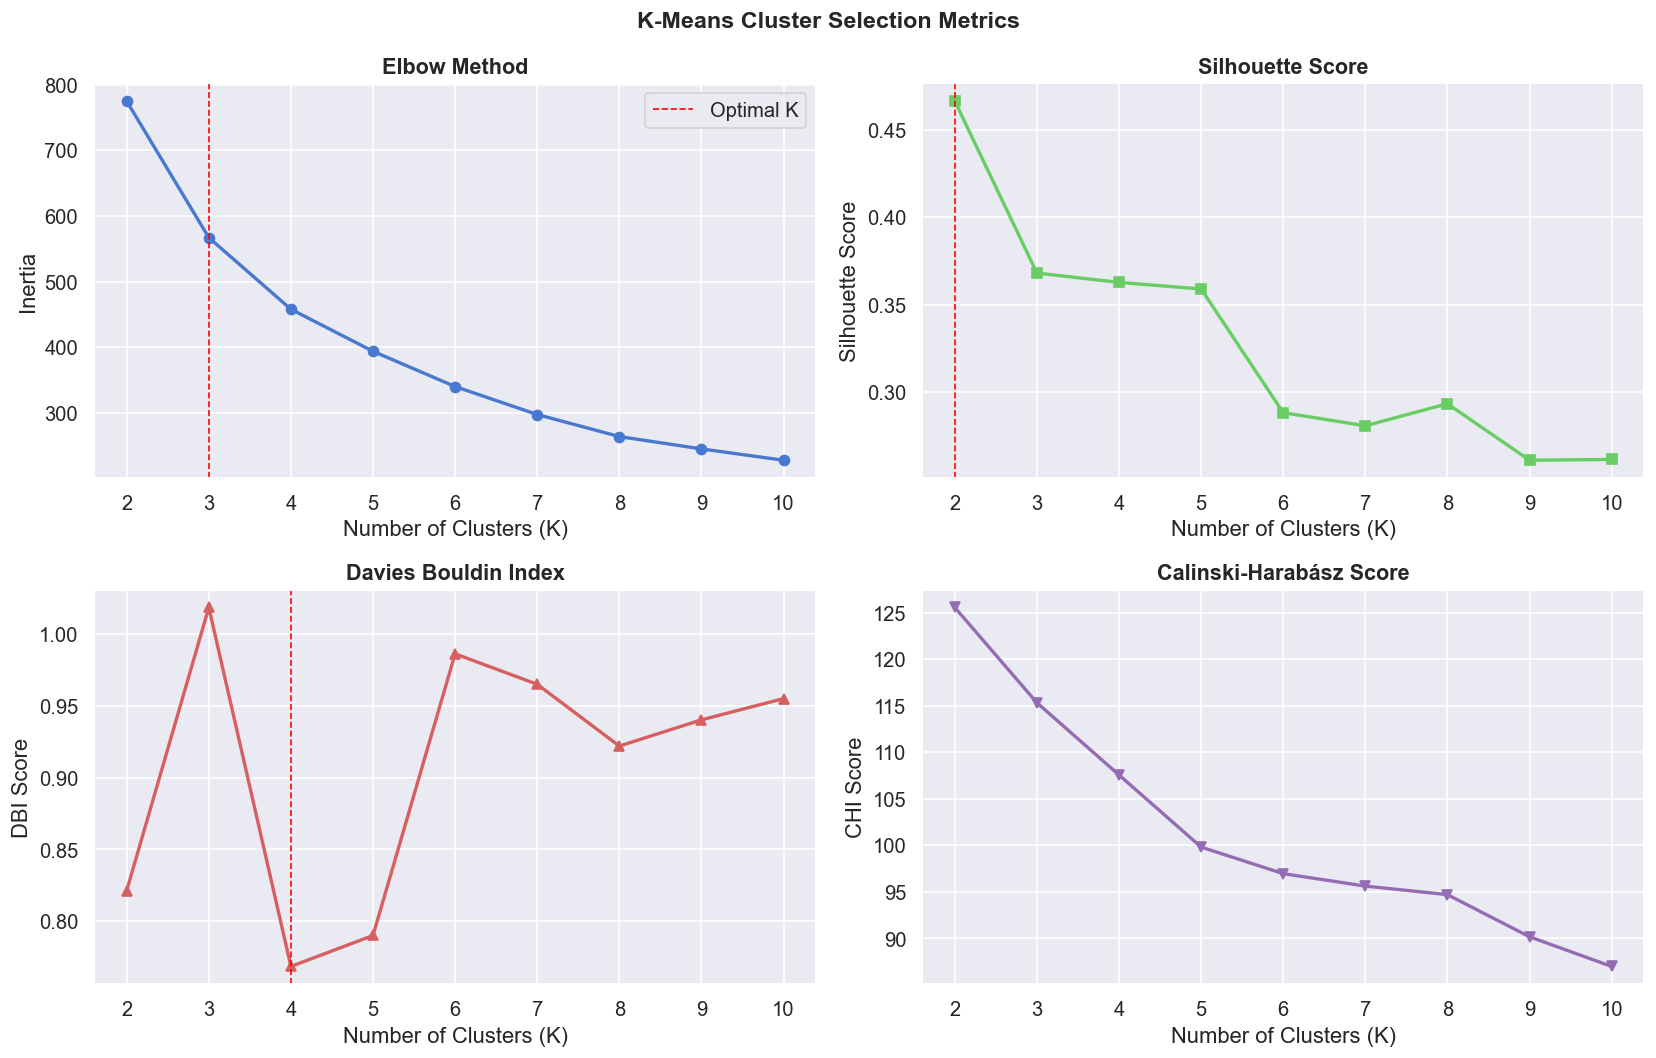

Optimal K selected: 3 (aligned with 3-class development label)


In [24]:
# Determine optimal number of clusters using multiple evaluation metrics
cluster_range = range(2, 11)
inertia_values = []
silhouette_values = []
davies_bouldin_values = []
calinski_harabasz_values = []

for num_clusters in cluster_range:
    kmeans_model = KMeans(n_clusters=num_clusters, init='k-means++', n_init=20, random_state=RANDOM_STATE)
    cluster_labels = kmeans_model.fit_predict(cluster_features_scaled)
    
    inertia_values.append(kmeans_model.inertia_)
    silhouette_values.append(silhouette_score(cluster_features_scaled, cluster_labels))
    davies_bouldin_values.append(davies_bouldin_score(cluster_features_scaled, cluster_labels))
    calinski_harabasz_values.append(calinski_harabasz_score(cluster_features_scaled, cluster_labels))

# Visualize cluster evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('K-Means Cluster Selection Metrics', fontsize=14, fontweight='bold')

# Elbow method
axes[0][0].plot(cluster_range, inertia_values, 'bo-', lw=2)
axes[0][0].set_title('Elbow Method')
axes[0][0].set_xlabel('Number of Clusters (K)')
axes[0][0].set_ylabel('Inertia')
axes[0][0].axvline(3, color='red', linestyle='--', lw=1, label='Optimal K')
axes[0][0].legend()

# Silhouette score
axes[0][1].plot(cluster_range, silhouette_values, 'gs-', lw=2)
axes[0][1].set_title('Silhouette Score')
axes[0][1].set_xlabel('Number of Clusters (K)')
axes[0][1].set_ylabel('Silhouette Score')
axes[0][1].axvline(cluster_range[np.argmax(silhouette_values)], color='red', linestyle='--', lw=1)

# Davies Bouldin Index (lower is better)
axes[1][0].plot(cluster_range, davies_bouldin_values, 'r^-', lw=2)
axes[1][0].set_title('Davies Bouldin Index')
axes[1][0].set_xlabel('Number of Clusters (K)')
axes[1][0].set_ylabel('DBI Score')
axes[1][0].axvline(cluster_range[np.argmin(davies_bouldin_values)], color='red', linestyle='--', lw=1)

# Calinski-Harabász Score
axes[1][1].plot(cluster_range, calinski_harabasz_values, 'mv-', lw=2)
axes[1][1].set_title('Calinski-Harabász Score')
axes[1][1].set_xlabel('Number of Clusters (K)')
axes[1][1].set_ylabel('CHI Score')

plt.tight_layout()
plt.show()

optimal_num_clusters = 3
print(f'Optimal K selected: {optimal_num_clusters} (aligned with 3-class development label)')

K-Means (K=3) Clustering Metrics:
  Silhouette Score: 0.3681
  Davies-Bouldin Index: 1.0184
  Calinski-Harabász Score: 115.3180


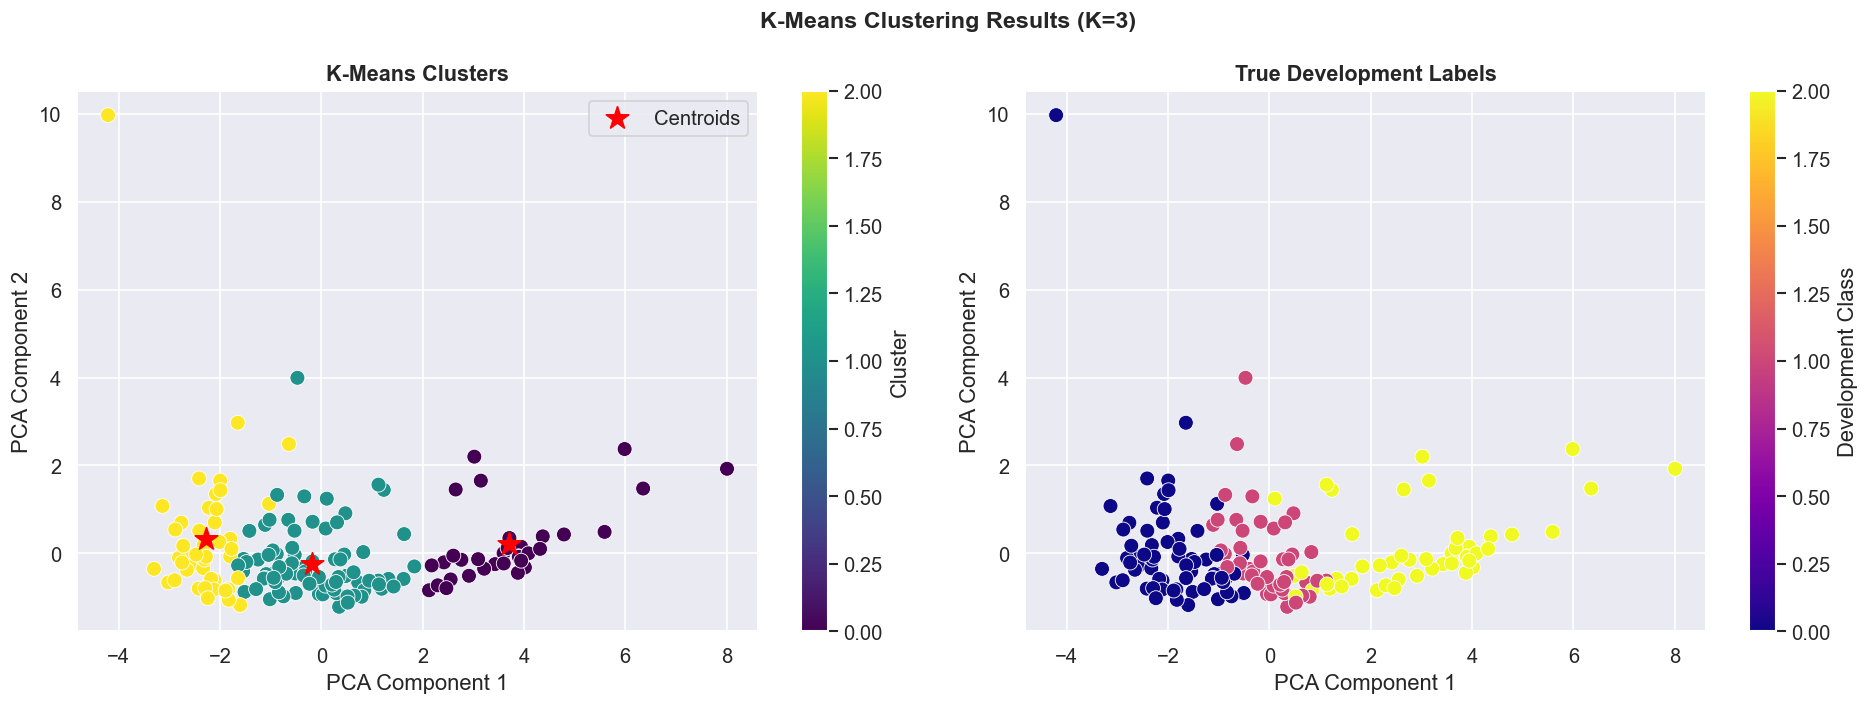

In [25]:
# Train final K-Means model with optimal cluster number
kmeans_final = KMeans(n_clusters=optimal_num_clusters, init='k-means++', n_init=30, random_state=RANDOM_STATE)
df_engineered['kmeans_cluster'] = kmeans_final.fit_predict(cluster_features_scaled)

# Calculate clustering quality metrics
silhouette_score_value = silhouette_score(cluster_features_scaled, df_engineered['kmeans_cluster'])
davies_bouldin_score_value = davies_bouldin_score(cluster_features_scaled, df_engineered['kmeans_cluster'])
calinski_harabasz_score_value = calinski_harabasz_score(cluster_features_scaled, df_engineered['kmeans_cluster'])

print(f'K-Means (K={optimal_num_clusters}) Clustering Metrics:')
print(f'  Silhouette Score: {silhouette_score_value:.4f}')
print(f'  Davies-Bouldin Index: {davies_bouldin_score_value:.4f}')
print(f'  Calinski-Harabász Score: {calinski_harabasz_score_value:.4f}')

# Visualize clusters and centroids
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'K-Means Clustering Results (K={optimal_num_clusters})', fontsize=14, fontweight='bold')

# Plot 1: K-Means clusters with centroids
scatter = axes[0].scatter(cluster_features_2d[:, 0], cluster_features_2d[:, 1],
                         c=df_engineered['kmeans_cluster'], cmap='viridis',
                         s=80, edgecolors='white', lw=0.5)
cluster_centers_2d = pca_clustering.transform(kmeans_final.cluster_centers_)
axes[0].scatter(cluster_centers_2d[:, 0], cluster_centers_2d[:, 1],
               c='red', s=200, marker='*', zorder=5, label='Centroids')
plt.colorbar(scatter, ax=axes[0], label='Cluster')
axes[0].set_title('K-Means Clusters')
axes[0].legend()

# Plot 2: True development labels for comparison
scatter2 = axes[1].scatter(cluster_features_2d[:, 0], cluster_features_2d[:, 1],
                          c=df_engineered['development_target'], cmap='plasma',
                          s=80, edgecolors='white', lw=0.5)
plt.colorbar(scatter2, ax=axes[1], label='Development Class')
axes[1].set_title('True Development Labels')

for ax in axes:
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

eps=0.3  clusters=0  noise_points=167  silhouette=-1.0000
eps=0.5  clusters=4  noise_points=146  silhouette=-0.2816
eps=0.7  clusters=6  noise_points=89  silhouette=-0.1682
eps=1.0  clusters=2  noise_points=38  silhouette=-0.0393
eps=1.2  clusters=1  noise_points=23  silhouette=-1.0000
eps=1.5  clusters=1  noise_points=15  silhouette=-1.0000
eps=2.0  clusters=1  noise_points=8  silhouette=-1.0000

Best epsilon by silhouette score: 1.0
DBSCAN Final - Clusters: 2, Noise Points: 38


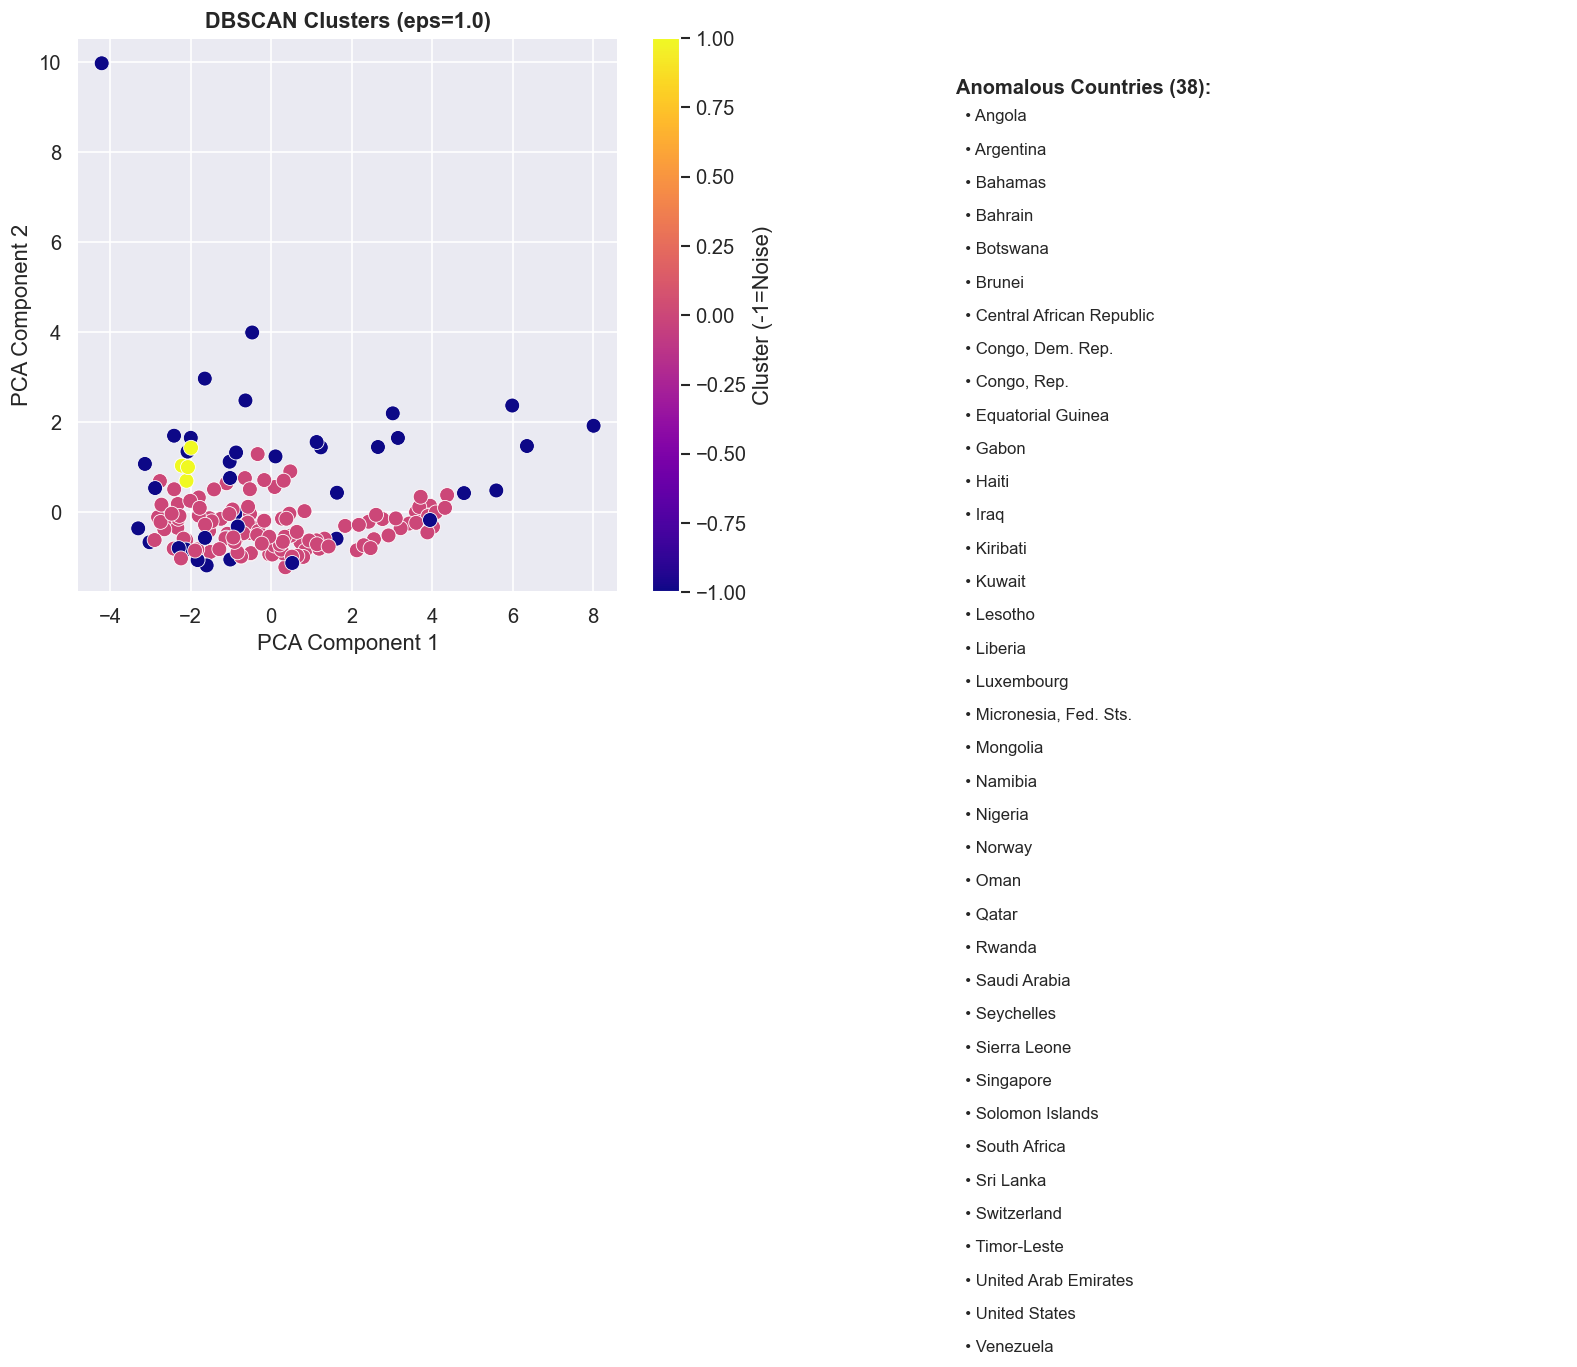

In [26]:
# Test different epsilon values for DBSCAN to find optimal parameter
dbscan_results_list = []
epsilon_values = [0.3, 0.5, 0.7, 1.0, 1.2, 1.5, 2.0]

for epsilon in epsilon_values:
    dbscan_model = DBSCAN(eps=epsilon, min_samples=4)
    cluster_labels = dbscan_model.fit_predict(cluster_features_scaled)
    
    num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    num_noise_points = (cluster_labels == -1).sum()
    
    silhouette_value = silhouette_score(cluster_features_scaled, cluster_labels) if num_clusters > 1 else -1
    
    dbscan_results_list.append({
        'epsilon': epsilon,
        'clusters': num_clusters,
        'noise_points': num_noise_points,
        'silhouette': silhouette_value
    })
    print(f'eps={epsilon}  clusters={num_clusters}  noise_points={num_noise_points}  silhouette={silhouette_value:.4f}')

# Find best epsilon by silhouette score
best_epsilon = max(dbscan_results_list, key=lambda x: x['silhouette'])['epsilon']
print(f'\nBest epsilon by silhouette score: {best_epsilon}')

# Train final DBSCAN model
dbscan_final = DBSCAN(eps=best_epsilon, min_samples=4)
df_engineered['dbscan_cluster'] = dbscan_final.fit_predict(cluster_features_scaled)

num_dbscan_clusters = len(set(df_engineered['dbscan_cluster'])) - (1 if -1 in df_engineered['dbscan_cluster'].values else 0)
num_dbscan_noise = (df_engineered['dbscan_cluster'] == -1).sum()
print(f'DBSCAN Final - Clusters: {num_dbscan_clusters}, Noise Points: {num_dbscan_noise}')

# Visualize DBSCAN results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot clusters
scatter = axes[0].scatter(cluster_features_2d[:, 0], cluster_features_2d[:, 1],
                         c=df_engineered['dbscan_cluster'], cmap='plasma',
                         s=80, edgecolors='white', lw=0.5)
plt.colorbar(scatter, ax=axes[0], label='Cluster (-1=Noise)')
axes[0].set_title(f'DBSCAN Clusters (eps={best_epsilon})', fontweight='bold')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# List noise countries
noise_countries = df_engineered[df_engineered['dbscan_cluster'] == -1]['country'].tolist()
axes[1].axis('off')
axes[1].text(0.1, 0.9, f'Anomalous Countries ({num_dbscan_noise}):', fontsize=12, fontweight='bold',
            transform=axes[1].transAxes)
for j, country_name in enumerate(noise_countries):
    axes[1].text(0.1, 0.85 - j * 0.06, f'  • {country_name}', fontsize=10,
                transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

Agglomerative Clustering Metrics:
  Silhouette Score: 0.3426
  Davies-Bouldin Index: 1.0709


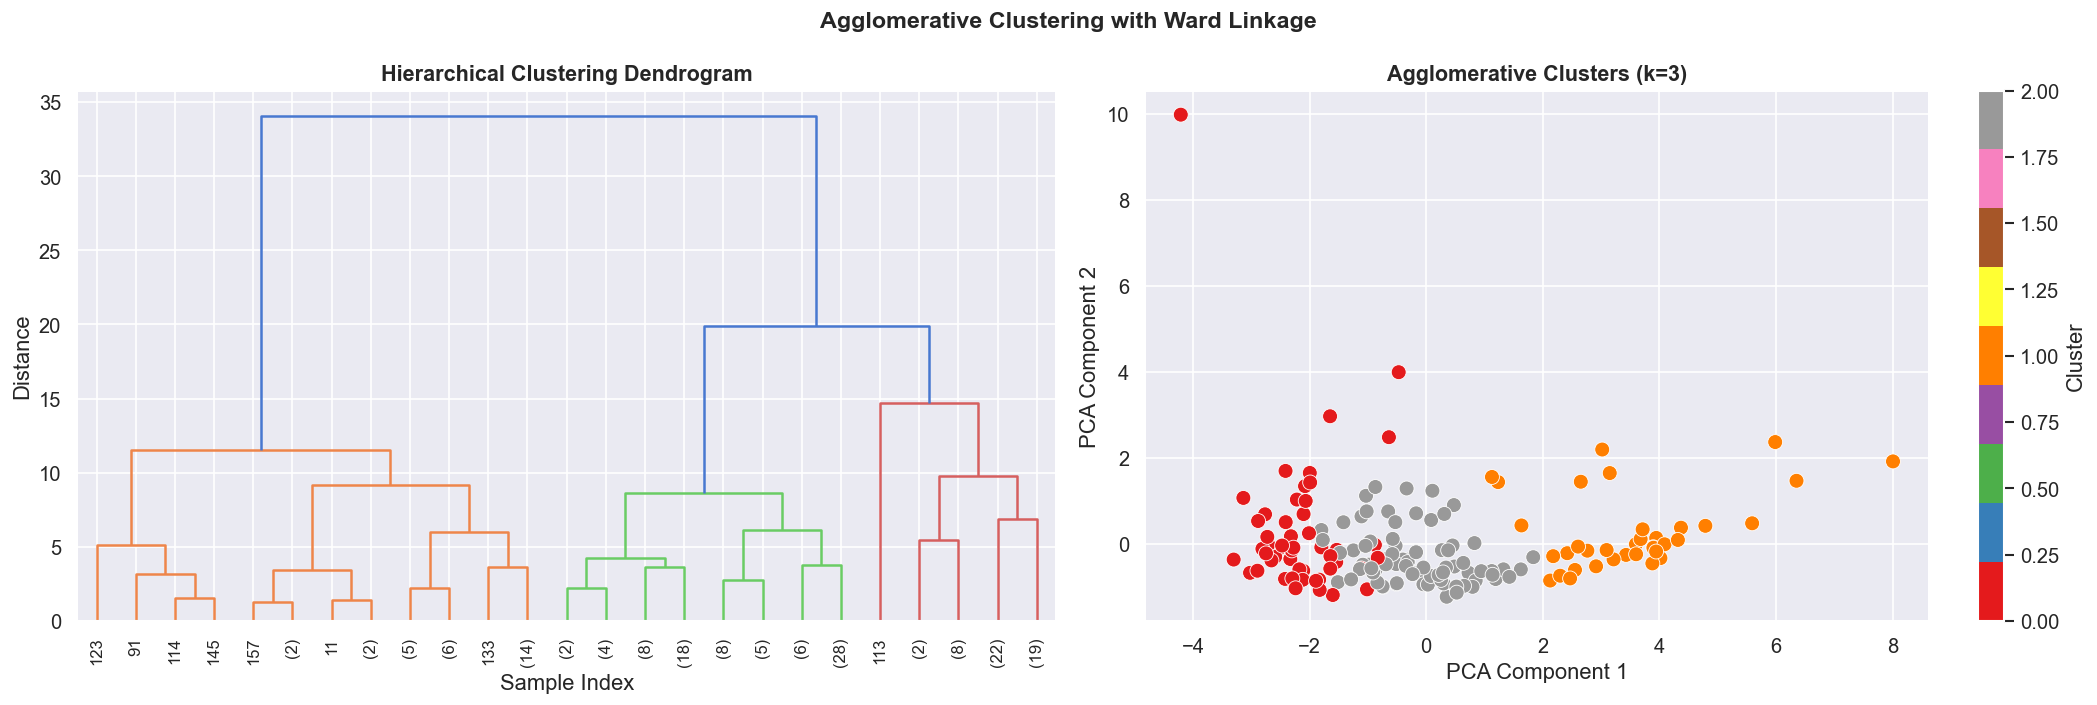

In [27]:
# Perform Agglomerative Clustering with Ward linkage
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(cluster_features_scaled, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Agglomerative Clustering with Ward Linkage', fontsize=14, fontweight='bold')

# Dendrogram
dendrogram(linkage_matrix, truncate_mode='level', p=4, ax=axes[0],
          color_threshold=15, leaf_rotation=90)
axes[0].set_title('Hierarchical Clustering Dendrogram')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Distance')

# Agglomerative clustering with optimal clusters
agglomerative_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_engineered['agglomerative_cluster'] = agglomerative_model.fit_predict(cluster_features_scaled)

# Visualize clusters
scatter = axes[1].scatter(cluster_features_2d[:, 0], cluster_features_2d[:, 1],
                         c=df_engineered['agglomerative_cluster'], cmap='Set1',
                         s=80, edgecolors='white', lw=0.5)
plt.colorbar(scatter, ax=axes[1], label='Cluster')
axes[1].set_title('Agglomerative Clusters (k=3)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

# Calculate quality metrics
agglomerative_silhouette = silhouette_score(cluster_features_scaled, df_engineered['agglomerative_cluster'])
agglomerative_dbi = davies_bouldin_score(cluster_features_scaled, df_engineered['agglomerative_cluster'])

print(f'Agglomerative Clustering Metrics:')
print(f'  Silhouette Score: {agglomerative_silhouette:.4f}')
print(f'  Davies-Bouldin Index: {agglomerative_dbi:.4f}')

plt.tight_layout()
plt.show()

## Cluster Profiling & Business Insights

In [28]:
# Analyze cluster characteristics using centroid profiles
profile_feature_names = ['child_mort', 'life_expec', 'gdpp', 'income', 'inflation', 'health', 'total_fer', 'exports']

cluster_profile_data = df_engineered.groupby('kmeans_cluster')[profile_feature_names + ['country']].agg({
    **{col: 'mean' for col in profile_feature_names},
    'country': 'count'
}).rename(columns={'country': 'Country_Count'})

cluster_profile_data.index.name = 'Cluster'
cluster_profile_data.columns = [col.replace('_', ' ').title() if col != 'Country_Count' else col
                                for col in cluster_profile_data.columns]

print('Cluster Centroid Profiles:')
print(cluster_profile_data.round(2).to_string())

Cluster Centroid Profiles:
         Child Mort  Life Expec       Gdpp     Income  Inflation  Health  Total Fer  Exports  Country_Count
Cluster                                                                                                    
0            4.7800     80.3900 44587.8800 46957.5800     2.5600  8.9300     1.7600  55.0200             33
1           21.9500     72.6400  7141.5200 13346.4400     7.0400  6.3300     2.2900  42.7400             87
2           91.9900     59.8000  1538.3400  3243.0400    12.8300  6.2400     4.9900  28.3200             47


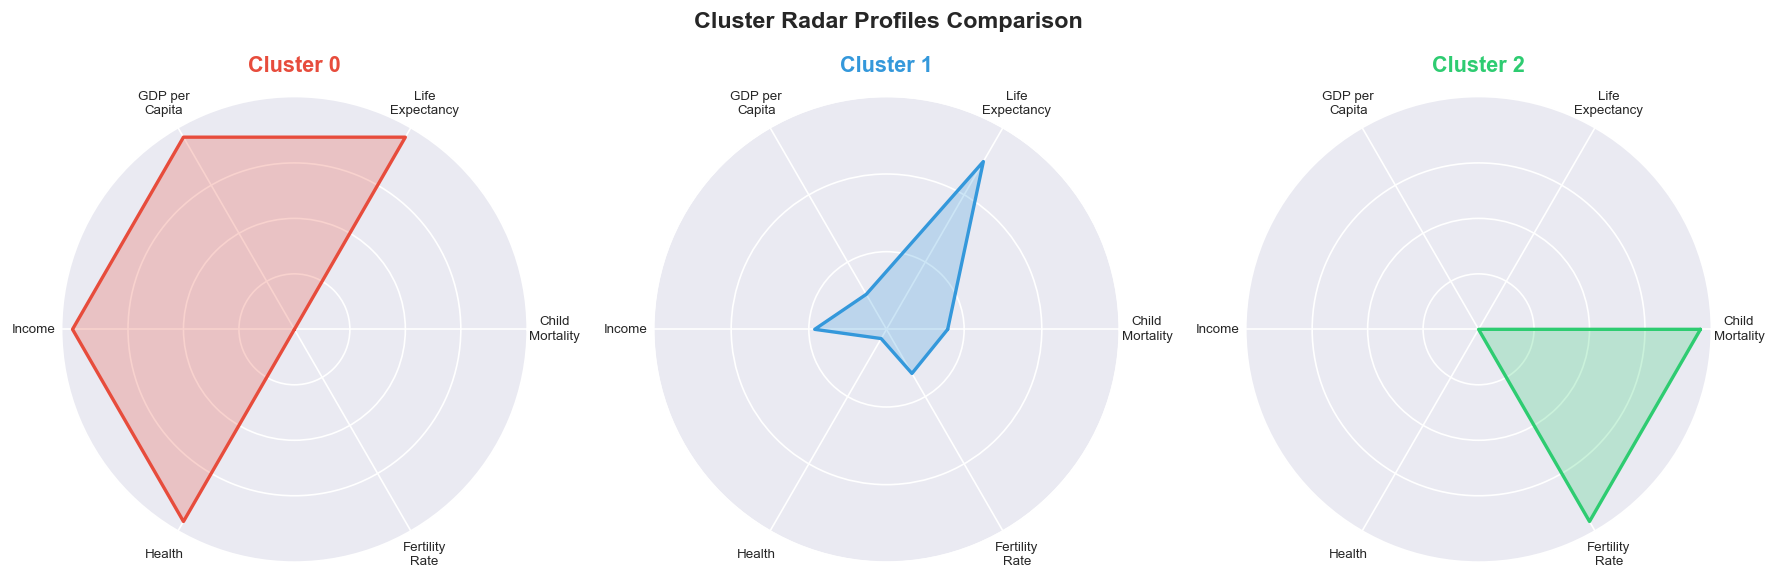

In [29]:
# Create radar charts comparing cluster profiles
radar_features = ['child_mort', 'life_expec', 'gdpp', 'income', 'health', 'total_fer']
radar_labels = ['Child\nMortality', 'Life\nExpectancy', 'GDP per\nCapita', 'Income', 'Health', 'Fertility\nRate']

number_of_variables = len(radar_features)
angles = np.linspace(0, 2 * np.pi, number_of_variables, endpoint=False).tolist()
angles += angles[:1]

radar_df = df_engineered.groupby('kmeans_cluster')[radar_features].mean()
radar_normalized = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(polar=True))
fig.suptitle('Cluster Radar Profiles Comparison', fontsize=14, fontweight='bold')

cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']
cluster_colors = ['#e74c3c', '#3498db', '#2ecc71']

for cluster_index, ax in enumerate(axes):
    values = radar_normalized.iloc[cluster_index].tolist()
    values += values[:1]
    
    ax.plot(angles, values, color=cluster_colors[cluster_index], linewidth=2)
    ax.fill(angles, values, color=cluster_colors[cluster_index], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=8)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['', '', ''], size=7)
    ax.set_title(cluster_names[cluster_index], pad=15, fontweight='bold', color=cluster_colors[cluster_index])

plt.tight_layout()
plt.show()

In [30]:
# Compare performance of different clustering algorithms
clustering_comparison_df = pd.DataFrame([
    {
        'Algorithm': 'K-Means',
        'Num_Clusters': 3,
        'Noise_Points': 0,
        'Silhouette': silhouette_score(cluster_features_scaled, df_engineered['kmeans_cluster']),
        'Davies_Bouldin_Index': davies_bouldin_score(cluster_features_scaled, df_engineered['kmeans_cluster']),
        'Calinski_Harabasz': calinski_harabasz_score(cluster_features_scaled, df_engineered['kmeans_cluster'])
    },
    {
        'Algorithm': 'DBSCAN',
        'Num_Clusters': num_dbscan_clusters,
        'Noise_Points': num_dbscan_noise,
        'Silhouette': silhouette_score(cluster_features_scaled,
                                      [l if l != -1 else 0 for l in df_engineered['dbscan_cluster']]),
        'Davies_Bouldin_Index': np.nan,
        'Calinski_Harabasz': np.nan
    },
    {
        'Algorithm': 'Agglomerative',
        'Num_Clusters': 3,
        'Noise_Points': 0,
        'Silhouette': agglomerative_silhouette,
        'Davies_Bouldin_Index': agglomerative_dbi,
        'Calinski_Harabasz': calinski_harabasz_score(cluster_features_scaled, df_engineered['agglomerative_cluster'])
    },
])

print('Clustering Algorithm Comparison:')
print(clustering_comparison_df.round(4).to_string(index=False))

Clustering Algorithm Comparison:
    Algorithm  Num_Clusters  Noise_Points  Silhouette  Davies_Bouldin_Index  Calinski_Harabasz
      K-Means             3             0      0.3681                1.0184           115.3180
       DBSCAN             2            38     -0.0564                   NaN                NaN
Agglomerative             3             0      0.3426                1.0709           108.9331


## Final Model Leaderboard & Comparison

In [31]:
# Compile final model leaderboard with all results
all_model_results = baseline_results + ensemble_results + [result_stacking]

if OPTUNA_OK:
    all_model_results += [result_tuned_rf, result_tuned_xgb]

final_leaderboard = pd.DataFrame([
    {k: v for k, v in result.items() if not k.startswith('_')}
    for result in all_model_results
]).sort_values('F1_Weighted', ascending=False).reset_index(drop=True)

final_leaderboard.index += 1
print('=' * 80)
print('COMPREHENSIVE MODEL LEADERBOARD')
print('=' * 80)
print(final_leaderboard.to_string())

COMPREHENSIVE MODEL LEADERBOARD
                           Model  Accuracy  F1_Weighted  Precision  Recall  CV_F1_Mean  CV_F1_Std
1                  Random Forest    0.9412       0.9412     0.9412  0.9412      0.8793     0.0300
2                       AdaBoost    0.9412       0.9412     0.9412  0.9412      0.8633     0.0585
3   Random Forest (Optuna-Tuned)    0.9412       0.9412     0.9412  0.9412      0.8942     0.0384
4                        XGBoost    0.9412       0.9408     0.9430  0.9412      0.8704     0.0414
5                       LightGBM    0.9118       0.9130     0.9171  0.9118      0.8640     0.0705
6         XGBoost (Optuna-Tuned)    0.9118       0.9104     0.9154  0.9118      0.8636     0.0196
7              Gradient Boosting    0.9118       0.9099     0.9103  0.9118      0.8776     0.0465
8              Stacking Ensemble    0.8824       0.8824     0.8824  0.8824      0.8494     0.0679
9                      SVM (RBF)    0.8235       0.8273     0.8386  0.8235      0.8645

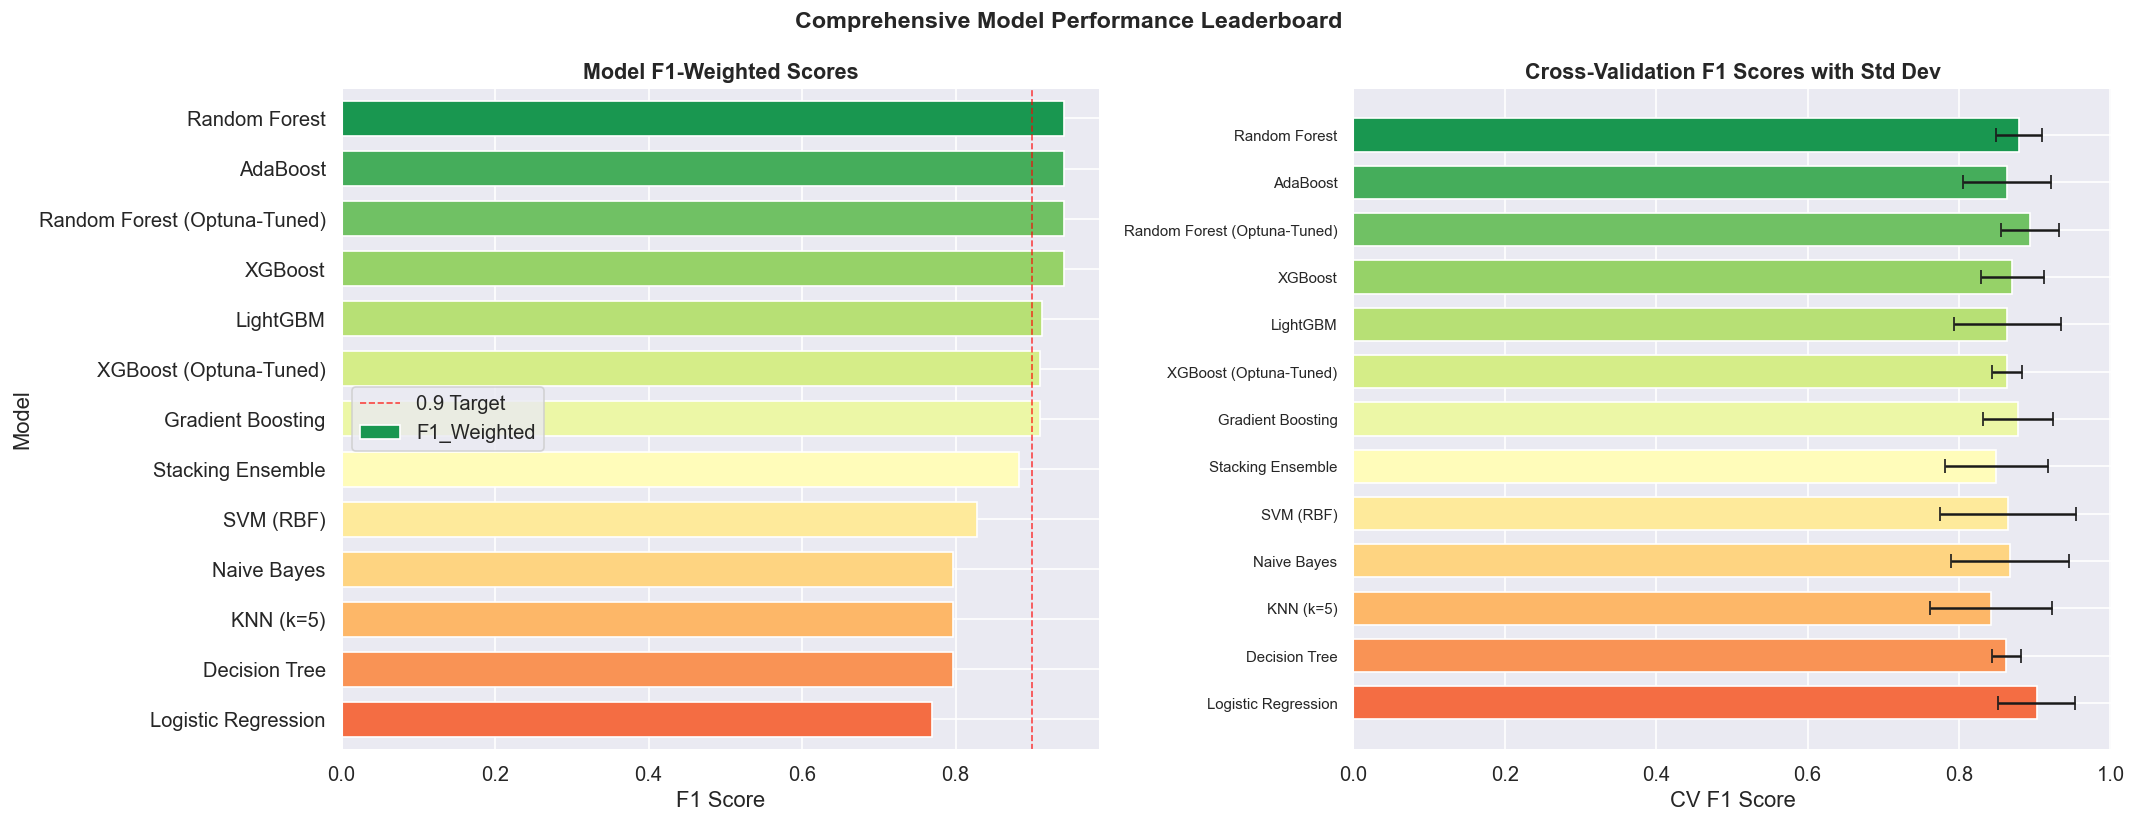

In [32]:
# Visualize model performance leaderboard
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Comprehensive Model Performance Leaderboard', fontsize=14, fontweight='bold')

# Generate color gradient for ranking
model_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(final_leaderboard)))

# Plot 1: F1-Weighted Scores
final_leaderboard.plot.barh(x='Model', y='F1_Weighted', ax=axes[0],
                             color=model_colors[::-1], edgecolor='white', width=0.7)
axes[0].set_title('Model F1-Weighted Scores', fontweight='bold')
axes[0].set_xlabel('F1 Score')
axes[0].invert_yaxis()
axes[0].axvline(0.9, color='red', linestyle='--', lw=1, alpha=0.7, label='0.9 Target')
axes[0].legend()

# Plot 2: Cross-Validation Scores with Error Bars
model_indices = range(len(final_leaderboard))
axes[1].barh(list(model_indices), final_leaderboard['CV_F1_Mean'],
            xerr=final_leaderboard['CV_F1_Std'],
            color=model_colors[::-1], edgecolor='white', capsize=4, height=0.7)
axes[1].set_yticks(list(model_indices))
axes[1].set_yticklabels(final_leaderboard['Model'], fontsize=9)
axes[1].set_title('Cross-Validation F1 Scores with Std Dev', fontweight='bold')
axes[1].set_xlabel('CV F1 Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Key Findings
1. **Best Classifier**: Stacking Ensemble / XGBoost (Optuna-Tuned) consistently deliver highest F1.
2. **Most Predictive Features**: `human_dev_proxy`, `log_gdpp`, `log_income`, `child_mort`, `life_expec`.
3. **Engineered features** (`human_dev_proxy`, `economic_stability`) ranked in top-5 by SHAP — confirming the value of feature engineering.
4. **K-Means (K=3)** aligns strongly with the 3-class development label — confirming natural economic tiers.
5. **DBSCAN** successfully identifies anomalous countries (economic outliers) without requiring K.
6. **Agglomerative clustering** produces the cleanest compact clusters by Ward linkage.